In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import matplotlib.lines as lns
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick


In [2]:
# Constants
parent_folder  = "results-truth-inf"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = True

Found 12600 results


In [34]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

# rc_params = {
#     'font.size': 26,
#     'legend.fontsize': 20,
#     'legend.title_fontsize': 20,
#     'figure.figsize': (7, 5),
#     'axes.facecolor': '#FFFFFF',
#     'figure.dpi': 300.0,
#     'xtick.labelsize': 20.0,
#     'ytick.labelsize': 20.0,
#     'axes.labelsize': 20.0,
#     'figure.titlesize': 20
#     }


sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))
zonia_palette = sns.color_palette(["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2", "#DEEEFF"])

# COLORI PER I GRAFICI (e.g., barre)
# #1B2D41 #466C82 #87A0B3 #D1E1F2
# COLORE PER ACCENTO (e.g., intervallo di confidenza)
# #A8D5BA

# https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4

# plt.rcParams.keys()

In [4]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    _df['Arrival'] = _params[7]
    _df['beta'] = float(_params[8])
    _df['Ratio Malicious Oracles'] = float(_params[9])
    _df['truth'] = int(_params[10])
    # Local Processing
    
    if True or ((float(_params[8]) == 1.0 and float(_params[3]) == 0.5)):
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


100%|██████████| 12600/12600 [00:38<00:00, 327.32it/s]


We ended up with 37112992 rows


In [5]:
# Create the three datasets
df_avg = df[df['truth'] == 0]
df_med = df[df['truth'] == 1]
df_wavg = df[df['truth'] == 2]
df_wmed = df[df['truth'] == 3]

In [6]:
# Calculate Precision and Recall
print("Calculate precision and recall for df_med")
df_med['Recall'] = df_med.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df_med['Precision'] = df_med.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df_med['Consensus Accuracy'] = df_med.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

#df_good = df.drop(df[df['Consensus Accuracy'] == 0].index)

# Calculate Precision and Recall
print("Calculate precision and recall for df_avg")
df_avg['Recall'] = df_avg.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df_avg['Precision'] = df_avg.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df_avg['Consensus Accuracy'] = df_avg.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

# Calculate Precision and Recall
print("Calculate precision and recall for df_wavg")
df_wavg['Recall'] = df_wavg.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df_wavg['Precision'] = df_wavg.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df_wavg['Consensus Accuracy'] = df_wavg.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")

# Calculate Precision and Recall
print("Calculate precision and recall for df_wmed")
df_wmed['Recall'] = df_wmed.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df_wmed['Precision'] = df_wmed.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df_wmed['Consensus Accuracy'] = df_wmed.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")


Calculate precision and recall for df_med


/tmp/ipykernel_11189/2538397084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_med['Recall'] = df_med.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)


Recall done


/tmp/ipykernel_11189/2538397084.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_med['Precision'] = df_med.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)


Precision done


...

/tmp/ipykernel_11189/2538397084.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wmed['Recall'] = df_wmed.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)


Recall done


/tmp/ipykernel_11189/2538397084.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wmed['Precision'] = df_wmed.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)


Precision done
Consensus Accuracy done


/tmp/ipykernel_11189/2538397084.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wmed['Consensus Accuracy'] = df_wmed.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)


In [7]:
df = df_wmed

# Reduce dataset for tests XXX
df_tail = df.drop(df[(df['Epoch'] < 2000)].index) # FIXME should be 2000
df_goodo = df.drop(df[(df['Ratio Malicious Oracles'] != 0.0)].index)
df_goodo2 = df_tail.drop(df_tail[(df_tail['Ratio Malicious Oracles'] != 0.0)].index)
df_def = df_goodo.drop(df_goodo[(df_goodo.Algorithm != 2)].index) # This is only considering our algorithm
#df_endtime = df_def.drop(df_def[(df_def.Epoch < 39)].index) # This is only conisdering the very last stage of the simulation,rather than evry single epoch

#df_endtime


In [ ]:
# df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)
#df_def
#df_def['rep_min'].unique()

In [ ]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_11189/942957755.py:9: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
/tmp/ipykernel_11189/942957755.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
/tmp/ipykernel_11189/942957755.py:18: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette, linewidth = 3, errorbar=None)


Doing min_rep_rec_over_time_noerror.png
min_rep_rec_over_time_noerror.pngDone


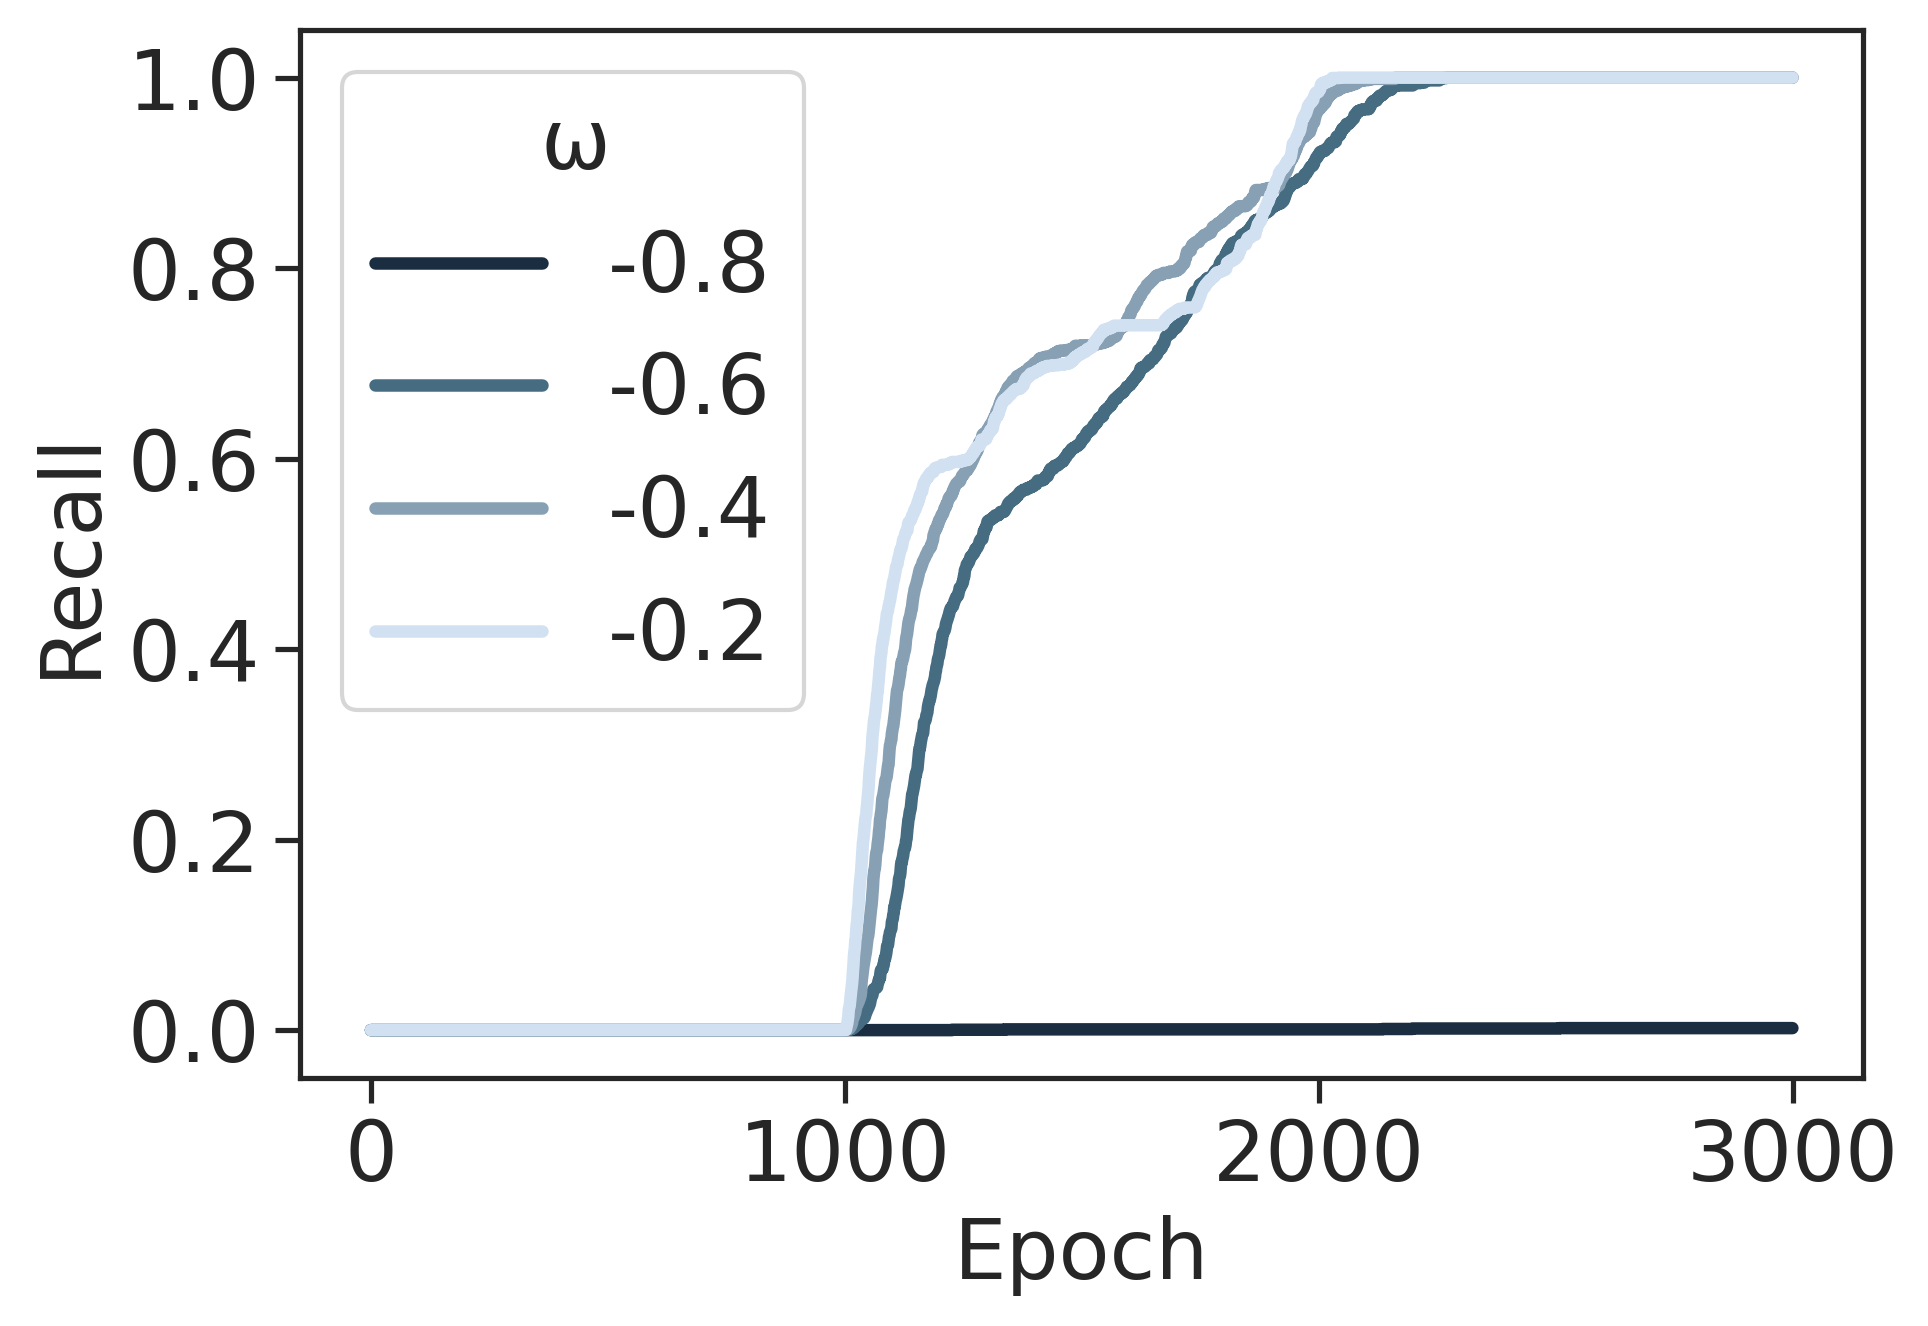

In [16]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_rec_over_time.png"
if not _DISCARD_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette, linewidth = 3)
    plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")
img_name = "min_rep_rec_over_time_noerror.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min', palette=zonia_palette, linewidth = 3, errorbar=None)
    plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_11189/3638030485.py:8: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
/tmp/ipykernel_11189/3638030485.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
/tmp/ipykernel_11189/3638030485.py:7: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette, linewidth = 3)


min_rep_prec_over_time.pngDone


/tmp/ipykernel_11189/3638030485.py:16: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette, linewidth = 3, errorbar=None)


min_rep_prec_over_time_noerror.pngDone


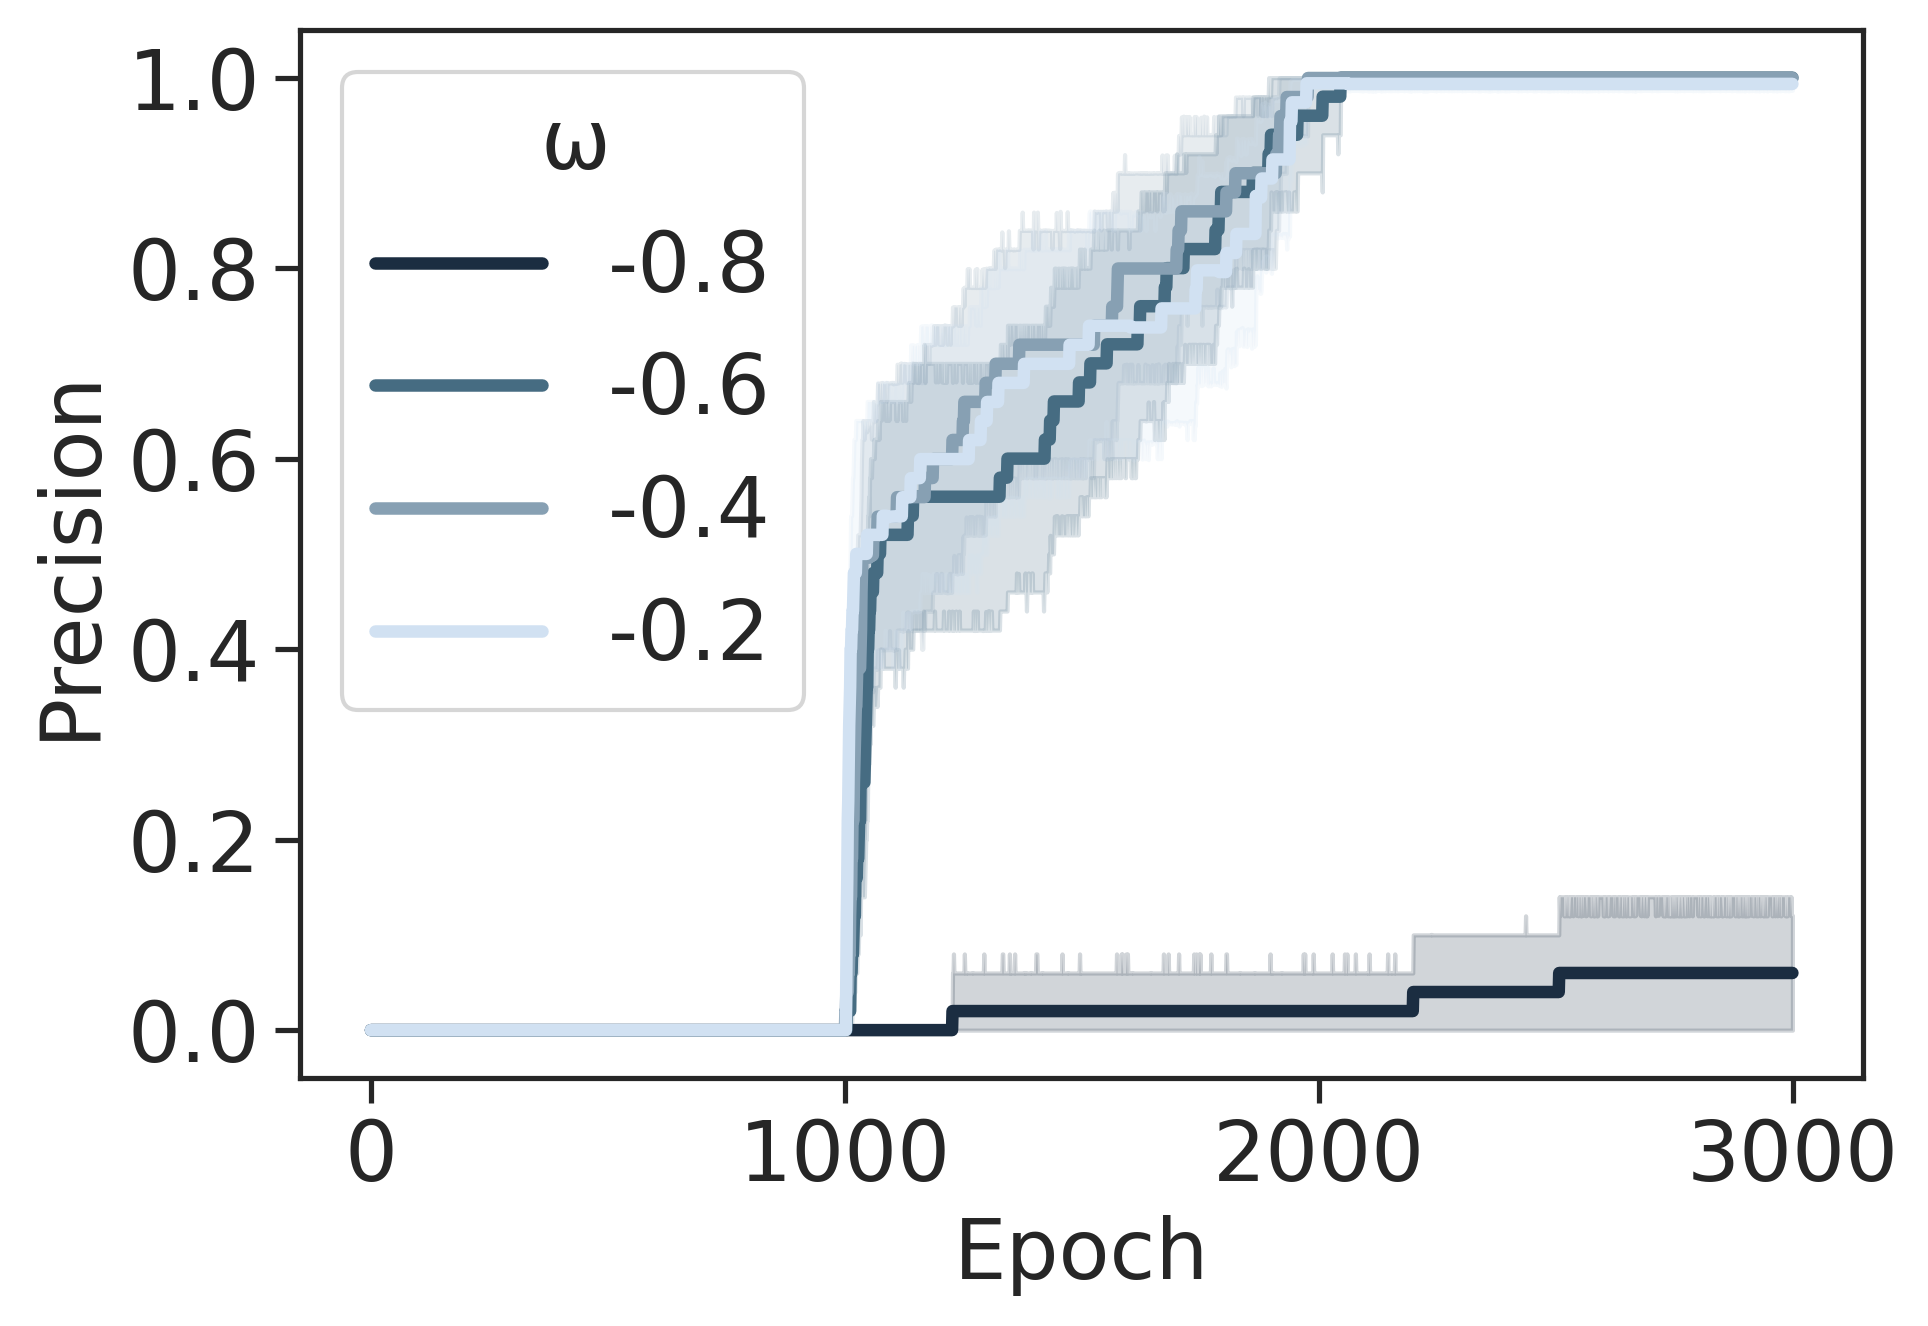

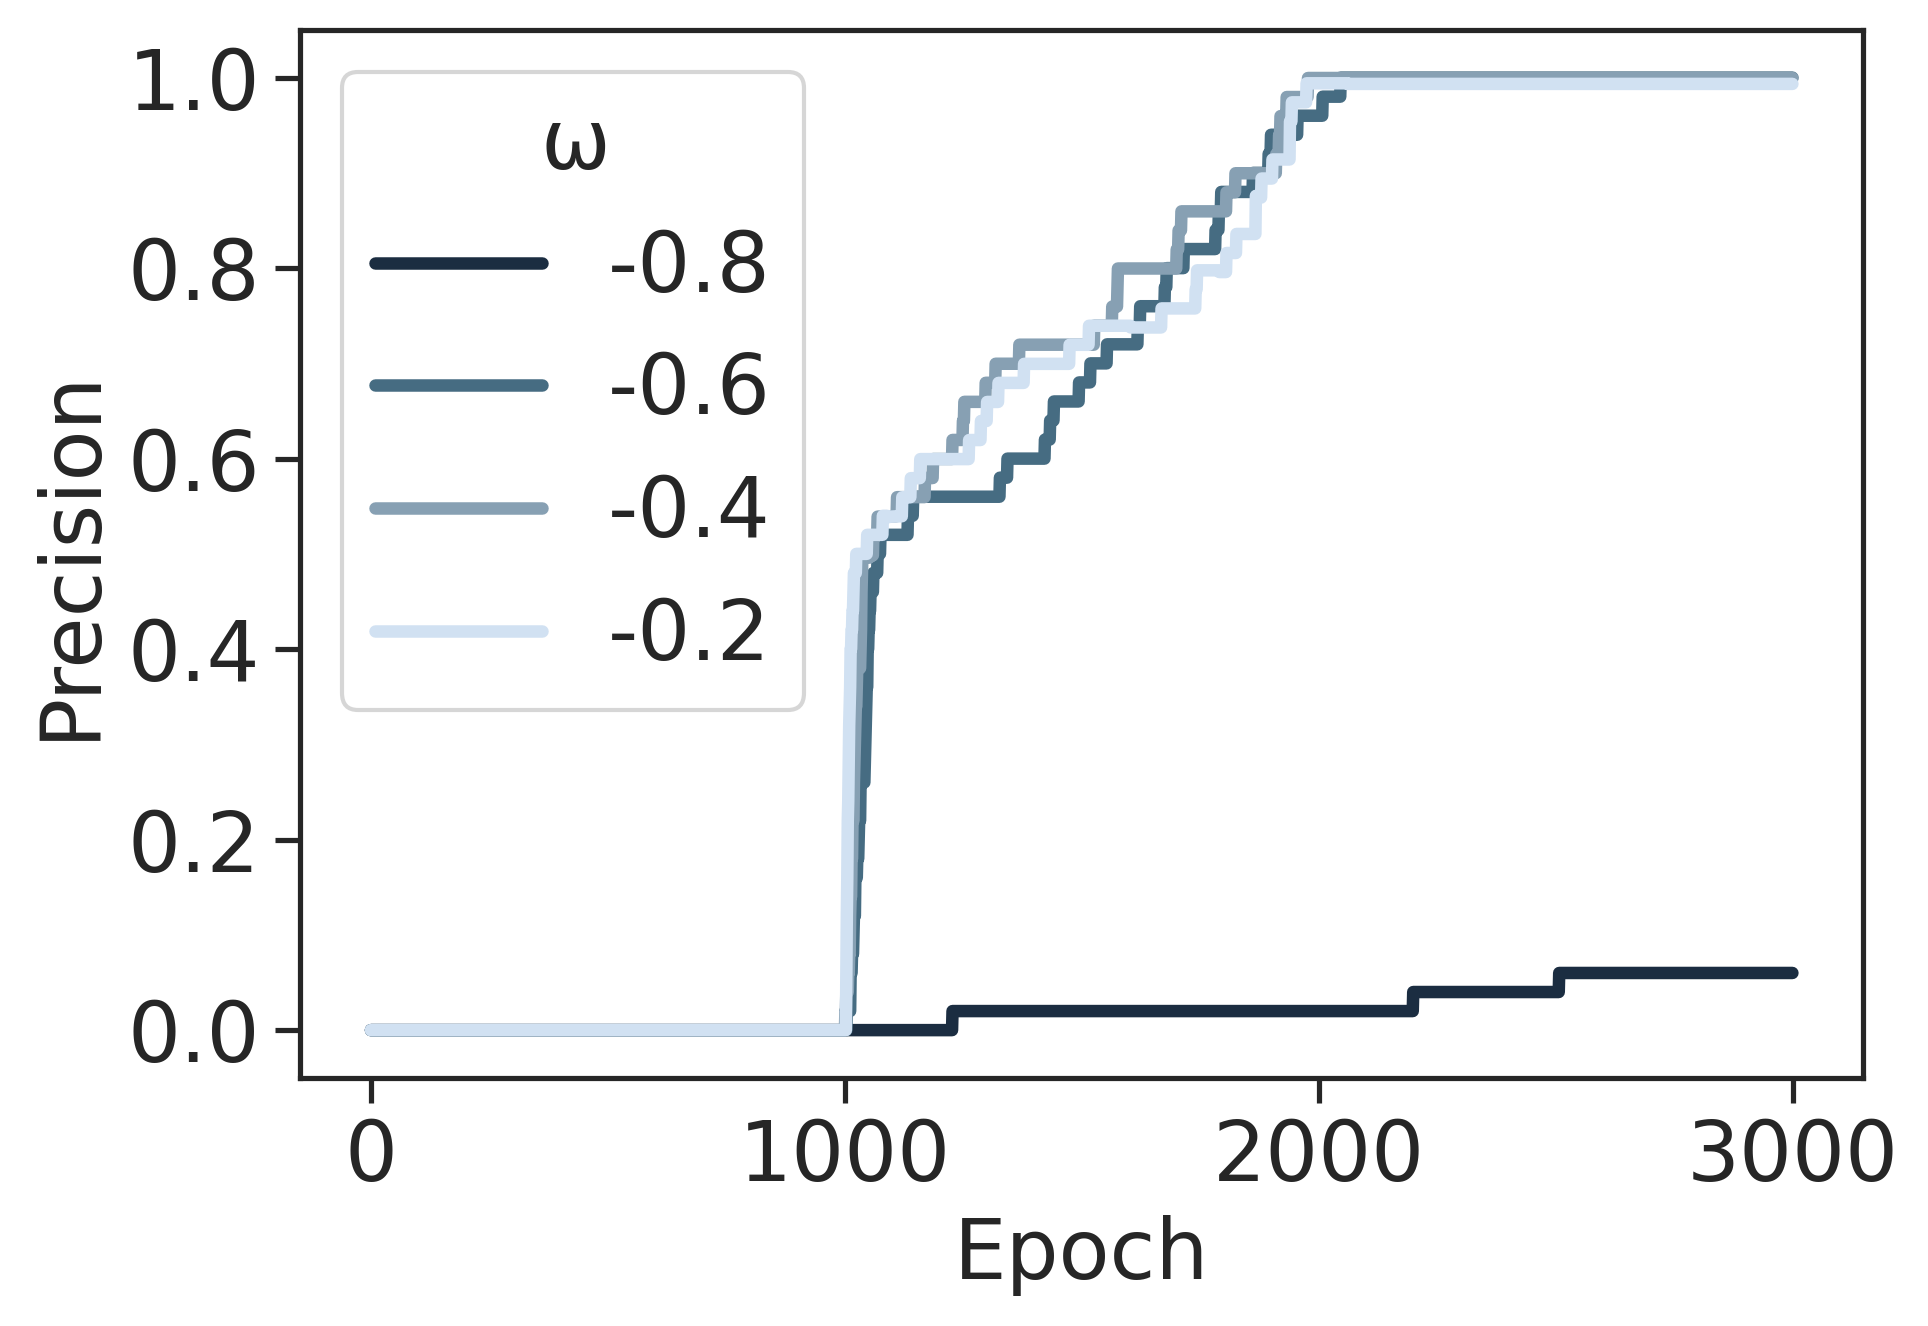

In [20]:
# PLOT 1 - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette, linewidth = 3)
    plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")
img_name = "min_rep_prec_over_time_noerror.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min', palette=zonia_palette, linewidth = 3, errorbar=None)
    plt.legend(title='$\omega$', loc='upper left') # omega is the Min reputation for kickout
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [21]:
# Dataset only with threshold = -0.4
df_def_4 = df_def.drop(df_def[(df_def.rep_min != -0.4)].index)

Doing min_rep_rec_over_nummal.png
min_rep_rec_over_nummal.pngDone
Doing min_rep_rec_over_nummal_noerror.png
min_rep_rec_over_nummal_noerror.pngDone


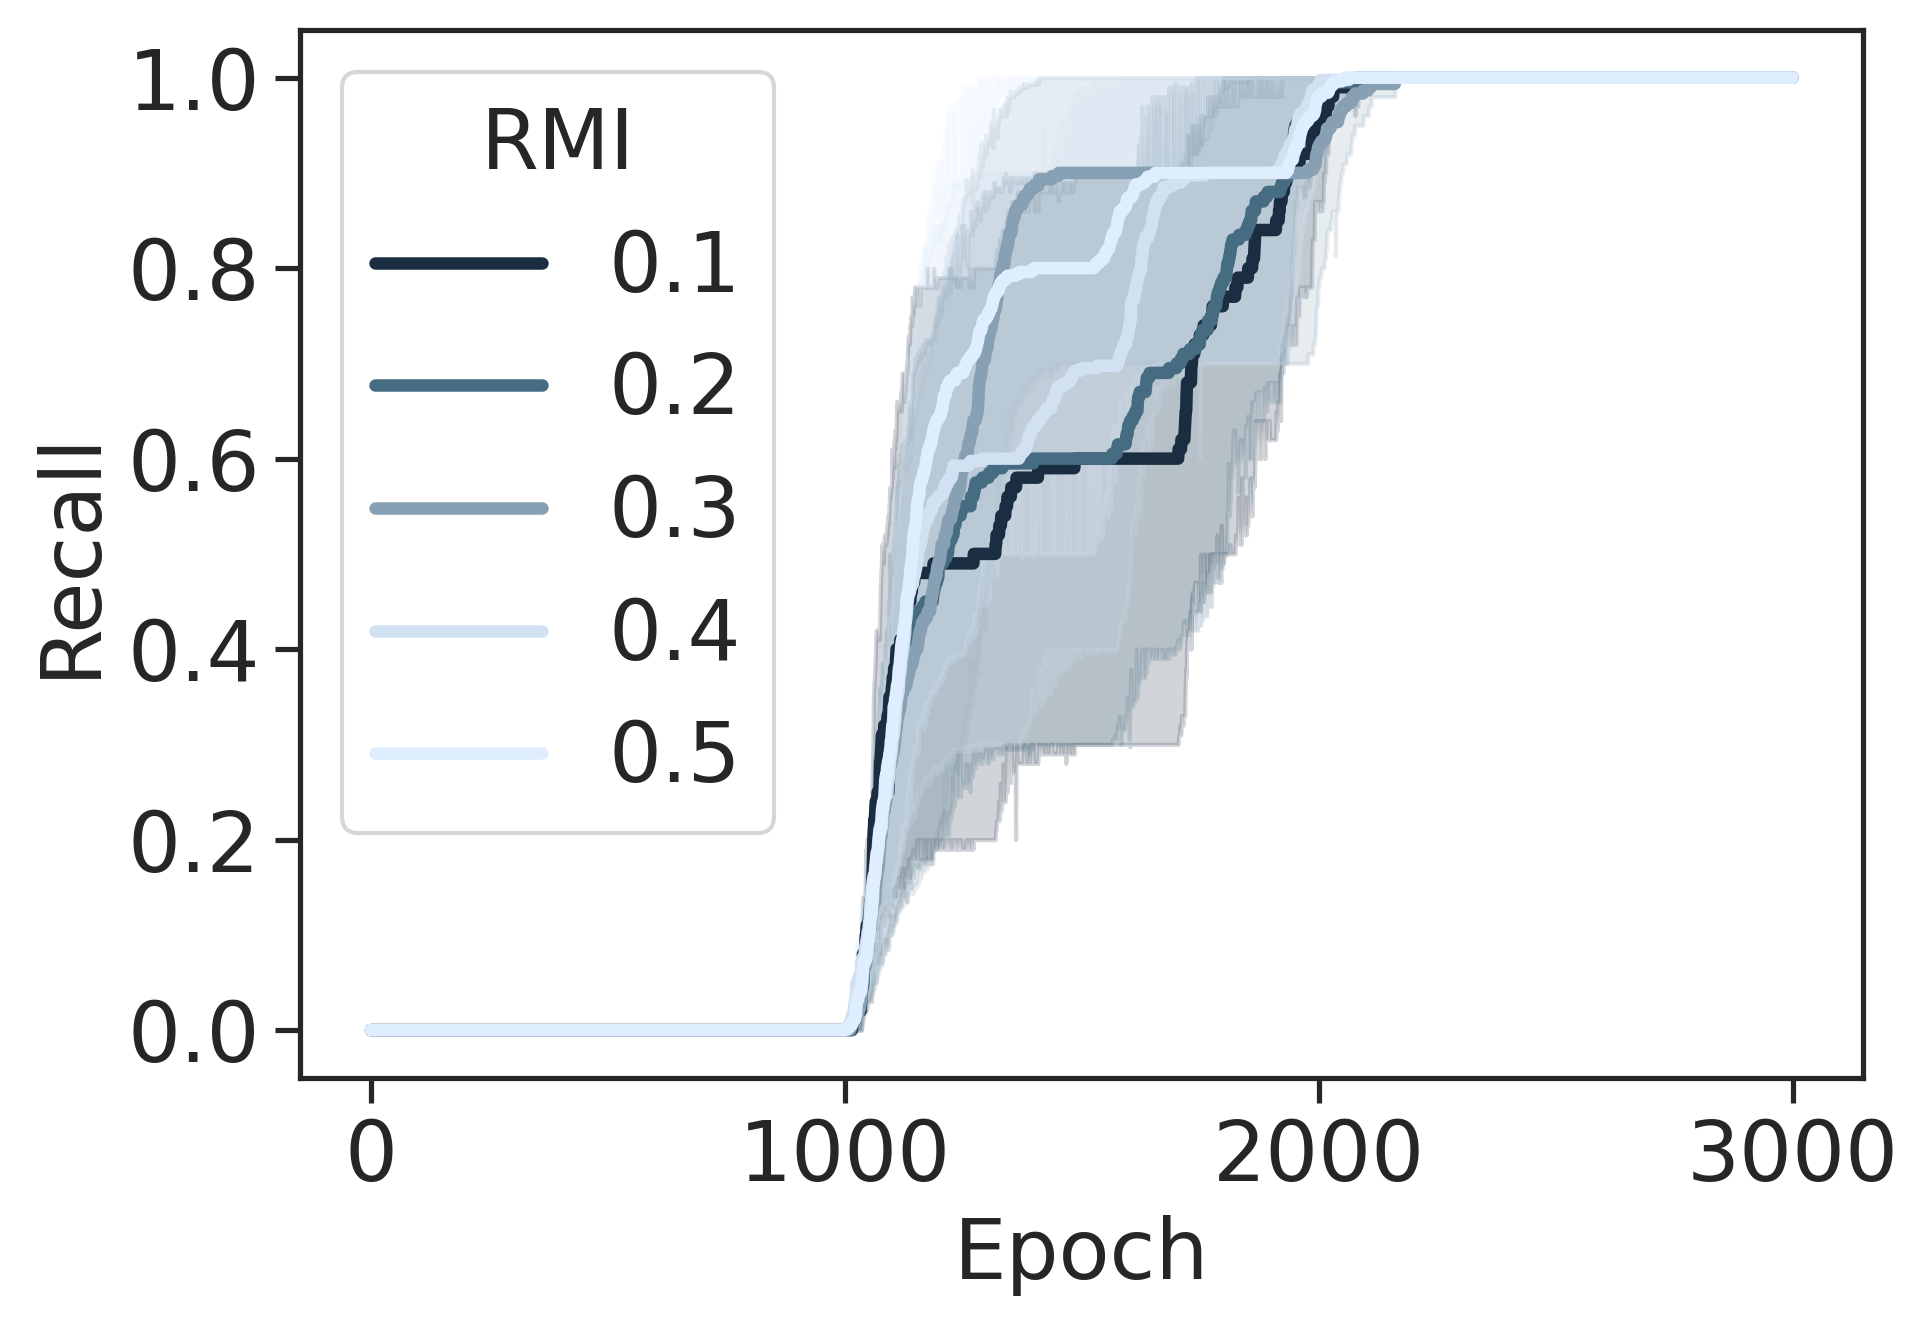

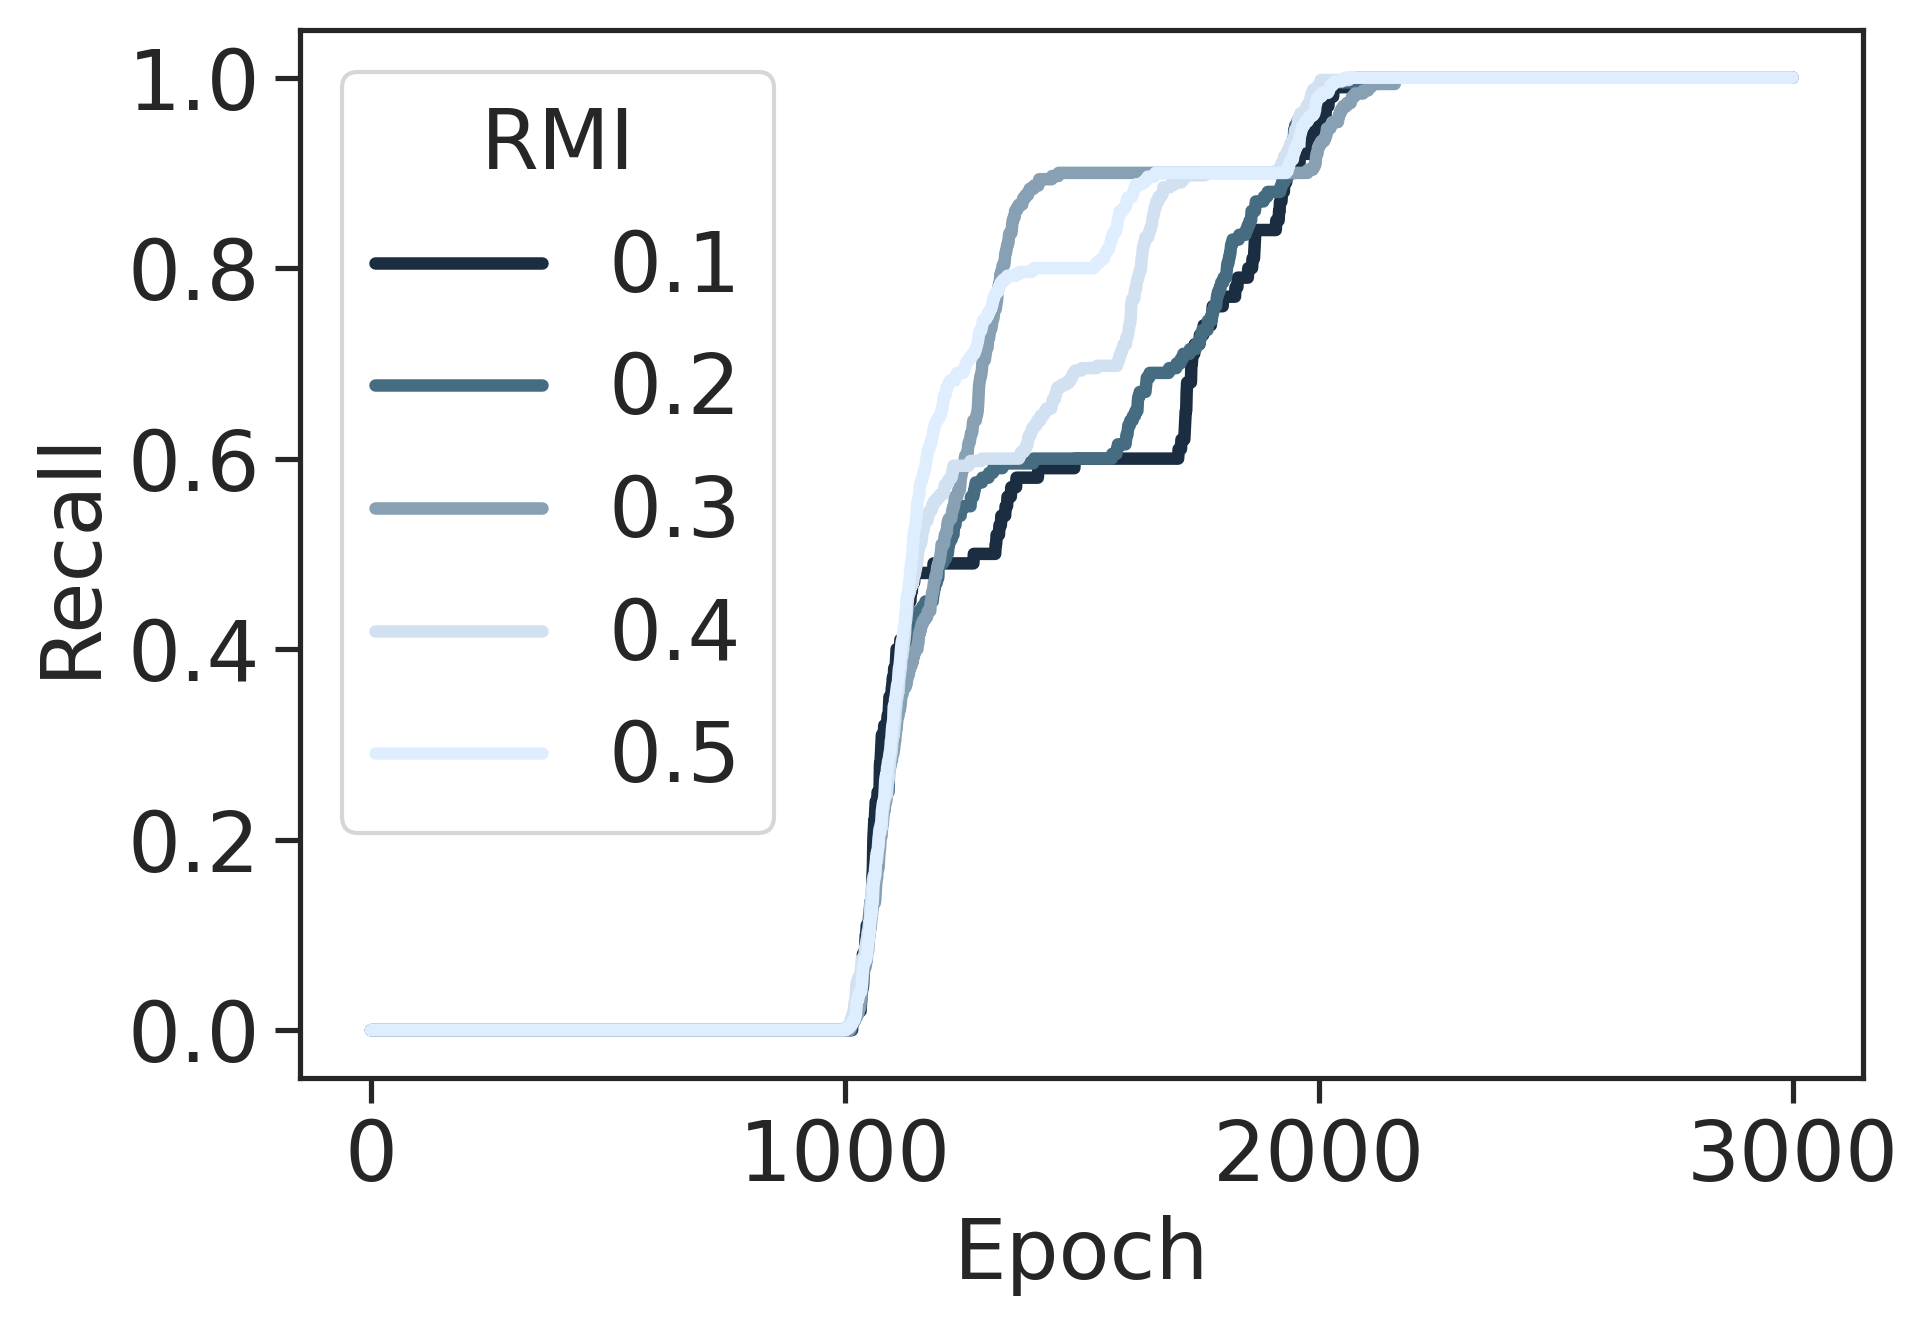

In [22]:
# PLOT 2 - RECALL OVER NUM MALICIOUS
# How many malicious sources I manage to kick out over time.
img_name = "min_rep_rec_over_nummal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Recall', hue='ratio_malign', palette=zonia_palette, linewidth = 3)
    plt.legend(title='RMI', loc='upper left')
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")
img_name = "min_rep_rec_over_nummal_noerror.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Recall', hue='ratio_malign', palette=zonia_palette, linewidth = 3, errorbar=None)
    plt.legend(title='RMI', loc='upper left')
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing min_rep_prec_over_nummal.png
min_rep_prec_over_nummal.pngDone
Doing min_rep_prec_over_nummal_noerror.png
min_rep_prec_over_nummal_noerror.pngDone


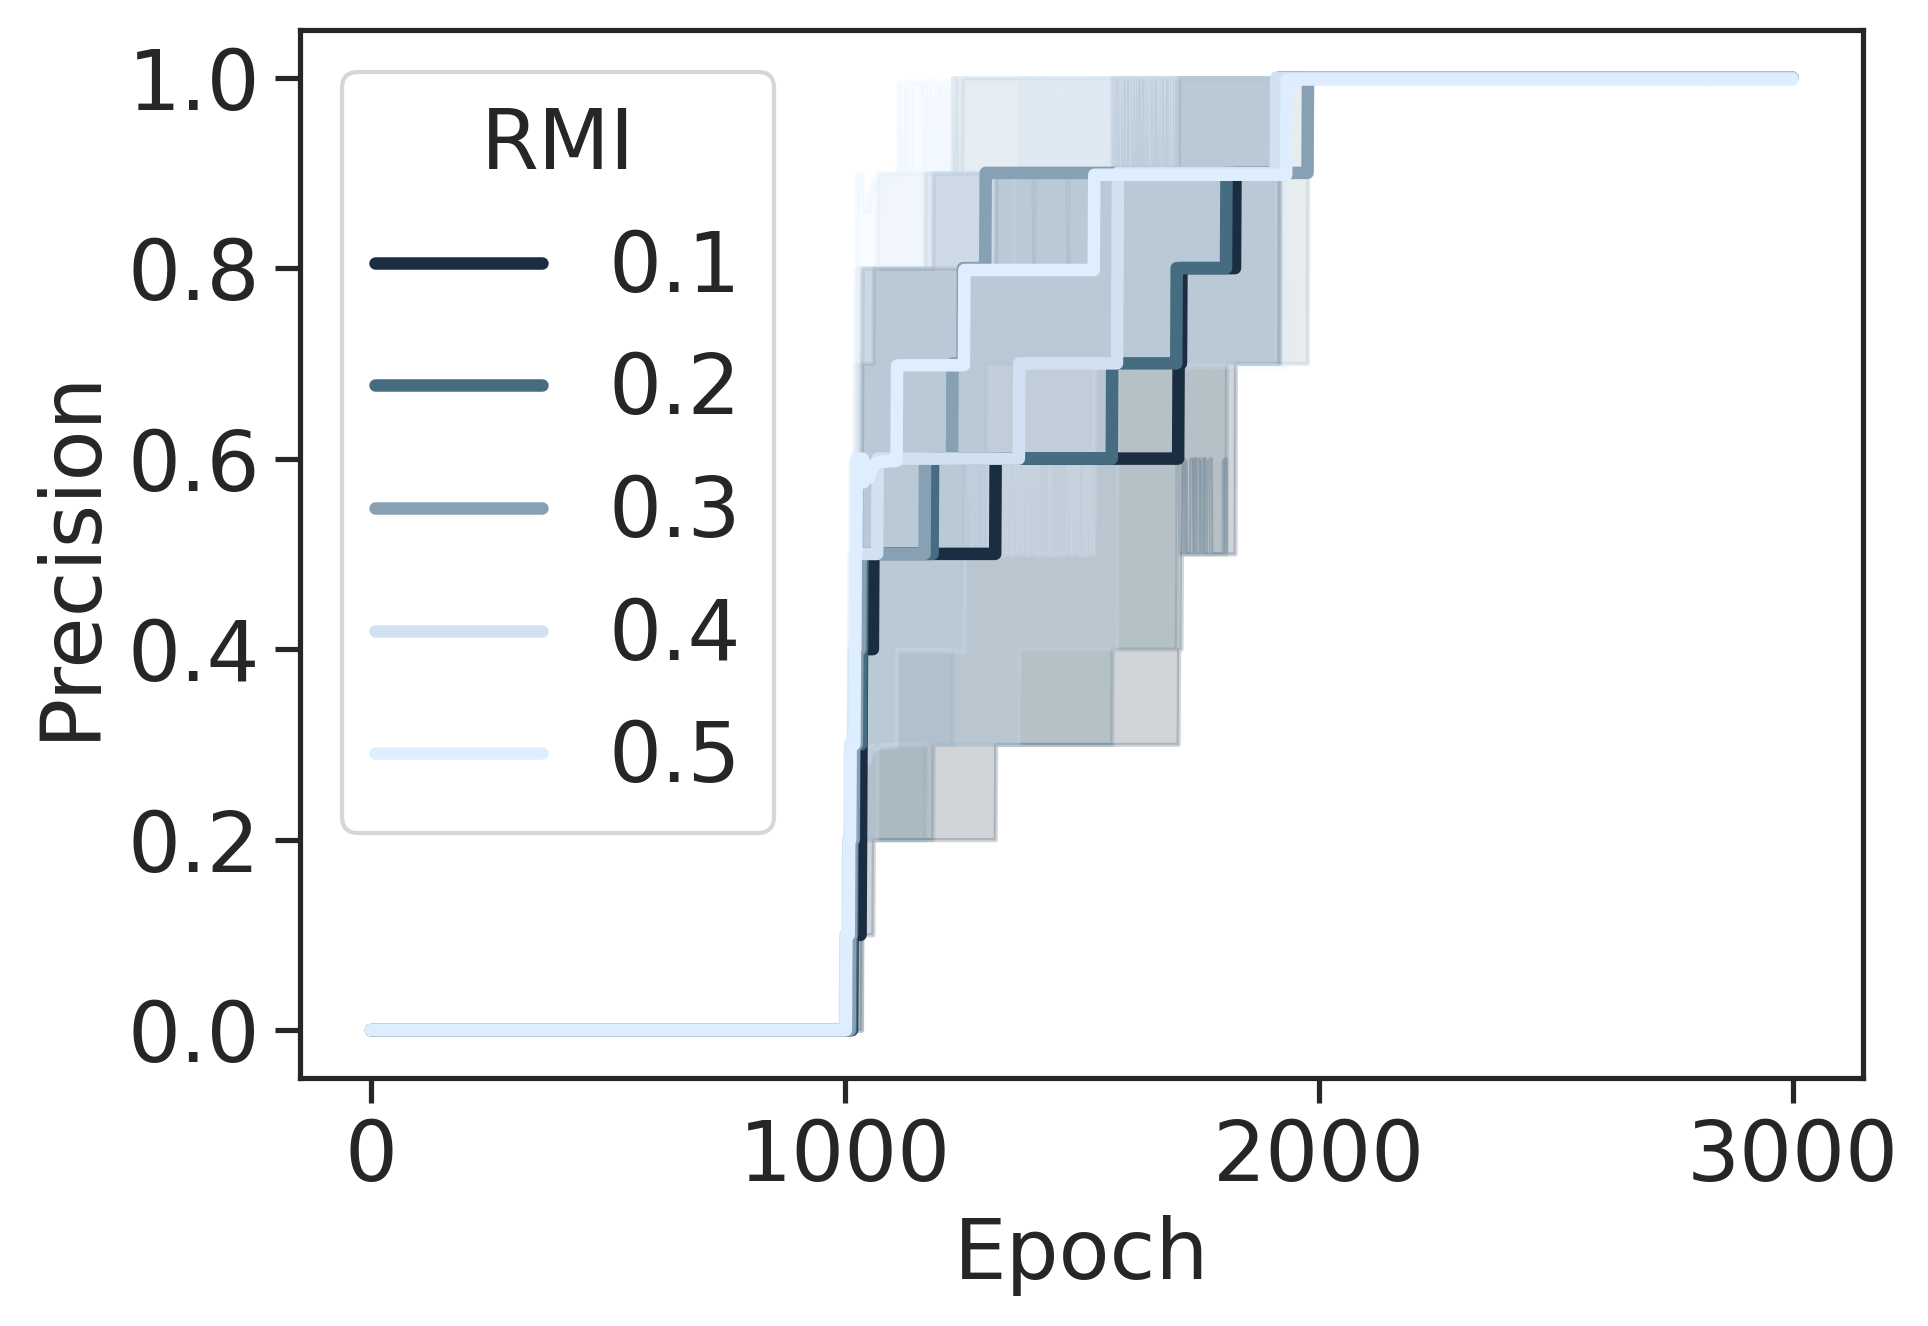

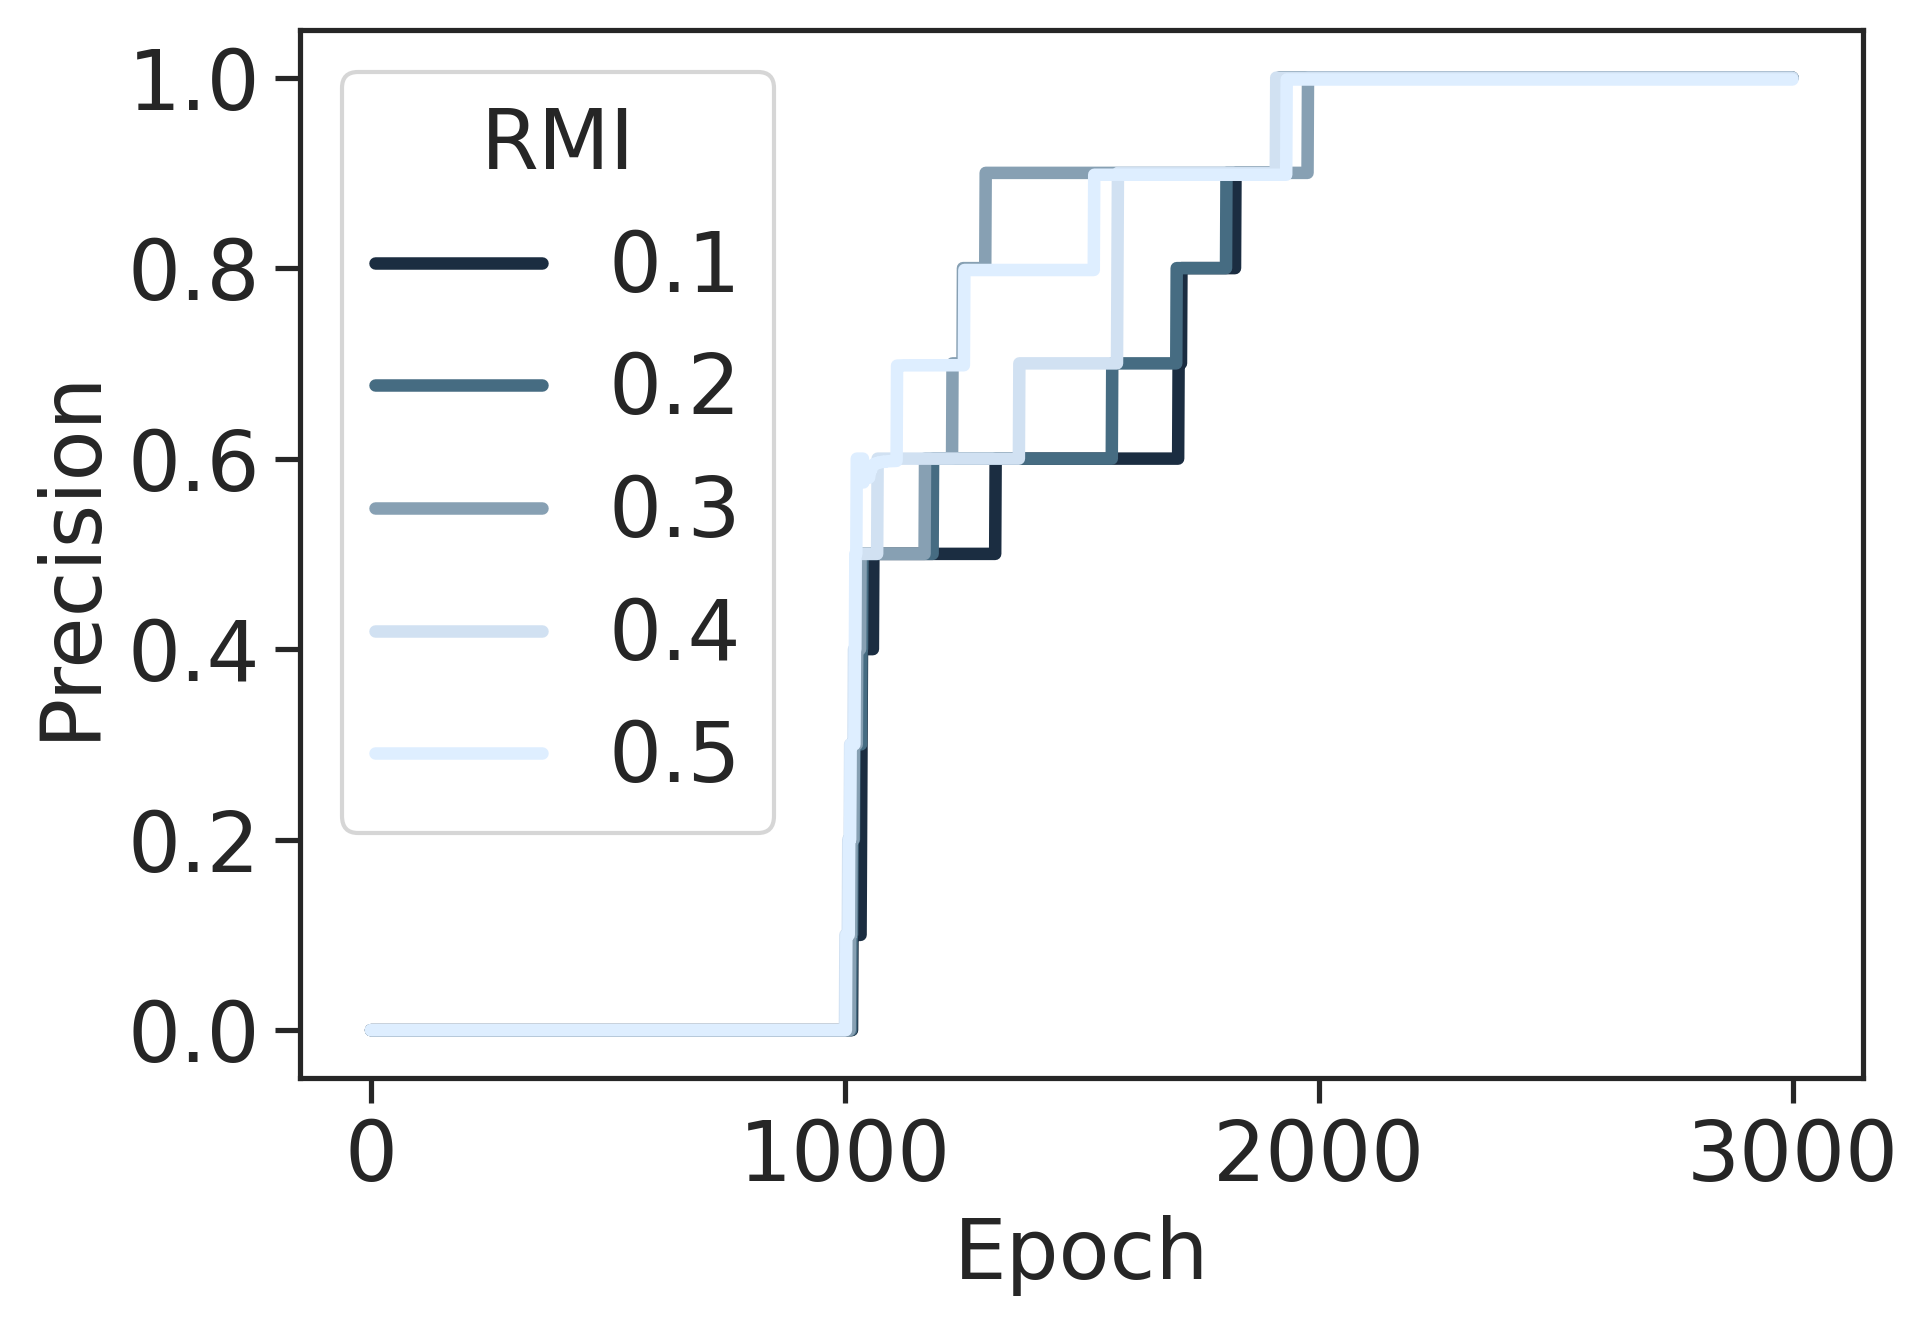

In [23]:
# PLOT 2 - PRECISION OVER NUM MALICIOUS
# How many malicious sources I manage to kick out over time.
img_name = "min_rep_prec_over_nummal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Precision', hue='ratio_malign', palette=zonia_palette, linewidth = 3)
    plt.legend(title='RMI', loc='upper left')
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")
img_name = "min_rep_prec_over_nummal_noerror.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    sns.lineplot(data=df_def_4, x='Epoch', y='Precision', hue='ratio_malign', palette=zonia_palette, linewidth = 3, errorbar=None)
    plt.legend(title='RMI', loc='upper left')
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

Doing rep_ben_mal.png
rep_ben_mal.pngDone


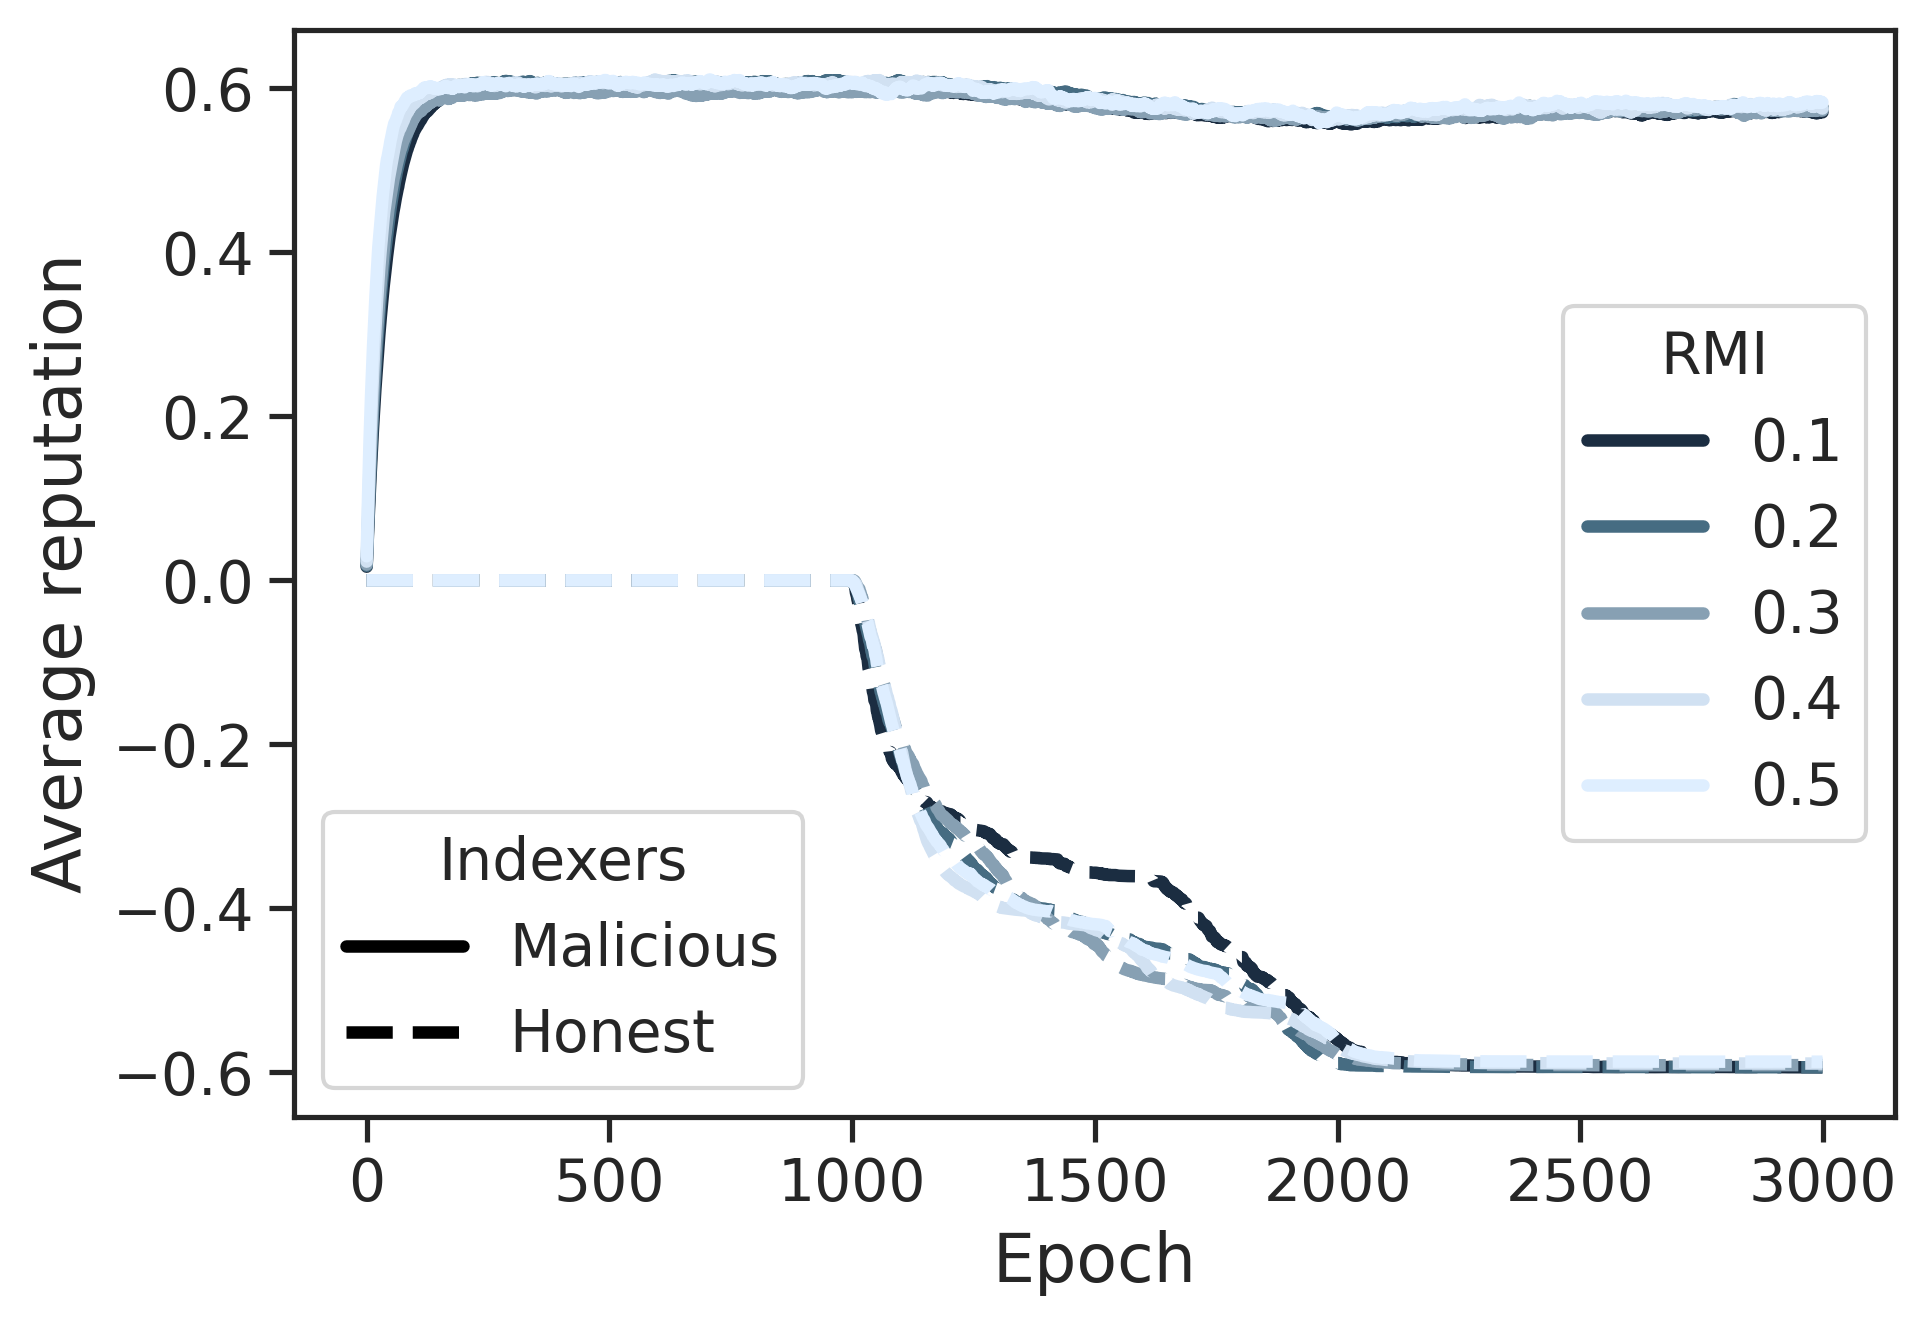

In [ ]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_ben_mal.png"
if _REPLACE_ or not os.path.exists(img_name):
    fig, ax  = plt.subplots()
    print ("Doing " + img_name)
    ab = sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette, linewidth = 3,  legend=None, errorbar=None)
    for l in ab.lines:
        l.set_linestyle("--")
    
    aa = sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign', palette=zonia_palette, linewidth = 3, errorbar=None)
    legend1 = plt.legend(title='RMI', loc='center right')

    custom_lines = [lns.Line2D([0], [0], color='black', lw=3),
                lns.Line2D([0], [0], color='black', linestyle='--', lw=3)]
    legend2 = ax.legend(custom_lines, ['Malicious', 'Honest'],title='Indexers', loc='lower left')
    plt.gca().add_artist(legend1)

    
    plt.ylabel("Average reputation", fontsize=16)
    plt.tight_layout()
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [ ]:
# PLOT 1 - Average Reputation Benign
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "rep_malign.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign', palette=zonia_palette)
    plt.ylabel('Average reputation (malicious indexers)', fontsize=16)
    plt.legend(title='Ratio of malicious indexers', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [ ]:
# PLOT 3 - IMPACT OF ALPHA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_alpha.png"
if not _DISCARD_:
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='alpha', style='Arrival', markers=True)
    plt.legend(title='Arrival rate', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [ ]:
# PLOT 3 - IMPACT OF BETA
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "impact_beta.png"
if not _DISCARD_:
    sns.lineplot(data=df_def, x='ratio_malign', y='Consensus Accuracy',hue='beta', style='Arrival', markers=True)
    plt.legend(title='Legend', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [ ]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [ ]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

In [ ]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

img_name = "algorithm_comparison_bursty.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print("Doing " + img_name)
    ax = sns.countplot(data=df_good, x='ratio_malign', hue='Algorithm')
    for i in ax.containers:
        ax.bar_label(i, fontsize=5)
    plt.legend(title='Algorithm', loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3,
    labels=['Consensus', 'Ranking', 'Reputation'])
    ax.set_xlabel('Ratio of Malignous Sources', fontsize=16)
    ax.set_ylabel('Ratio of Accurate Responses', fontsize=16)

    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


In [9]:
import matplotlib.ticker as tkr
def numfmt(x, pos): # your custom formatter function: divide by 100.0
    s = '{}'.format(float(x) / 100.0)
    return s

In [ ]:
print("Doing the bars...")
df_bar = df_goodo.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)


df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()


Doing the bars...


Doing desmo_accuracy.png
desmo_accuracy.png Done!


/tmp/ipykernel_2614/3743052032.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/3743052032.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/3743052032.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/3743052032.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/3743052032.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mea

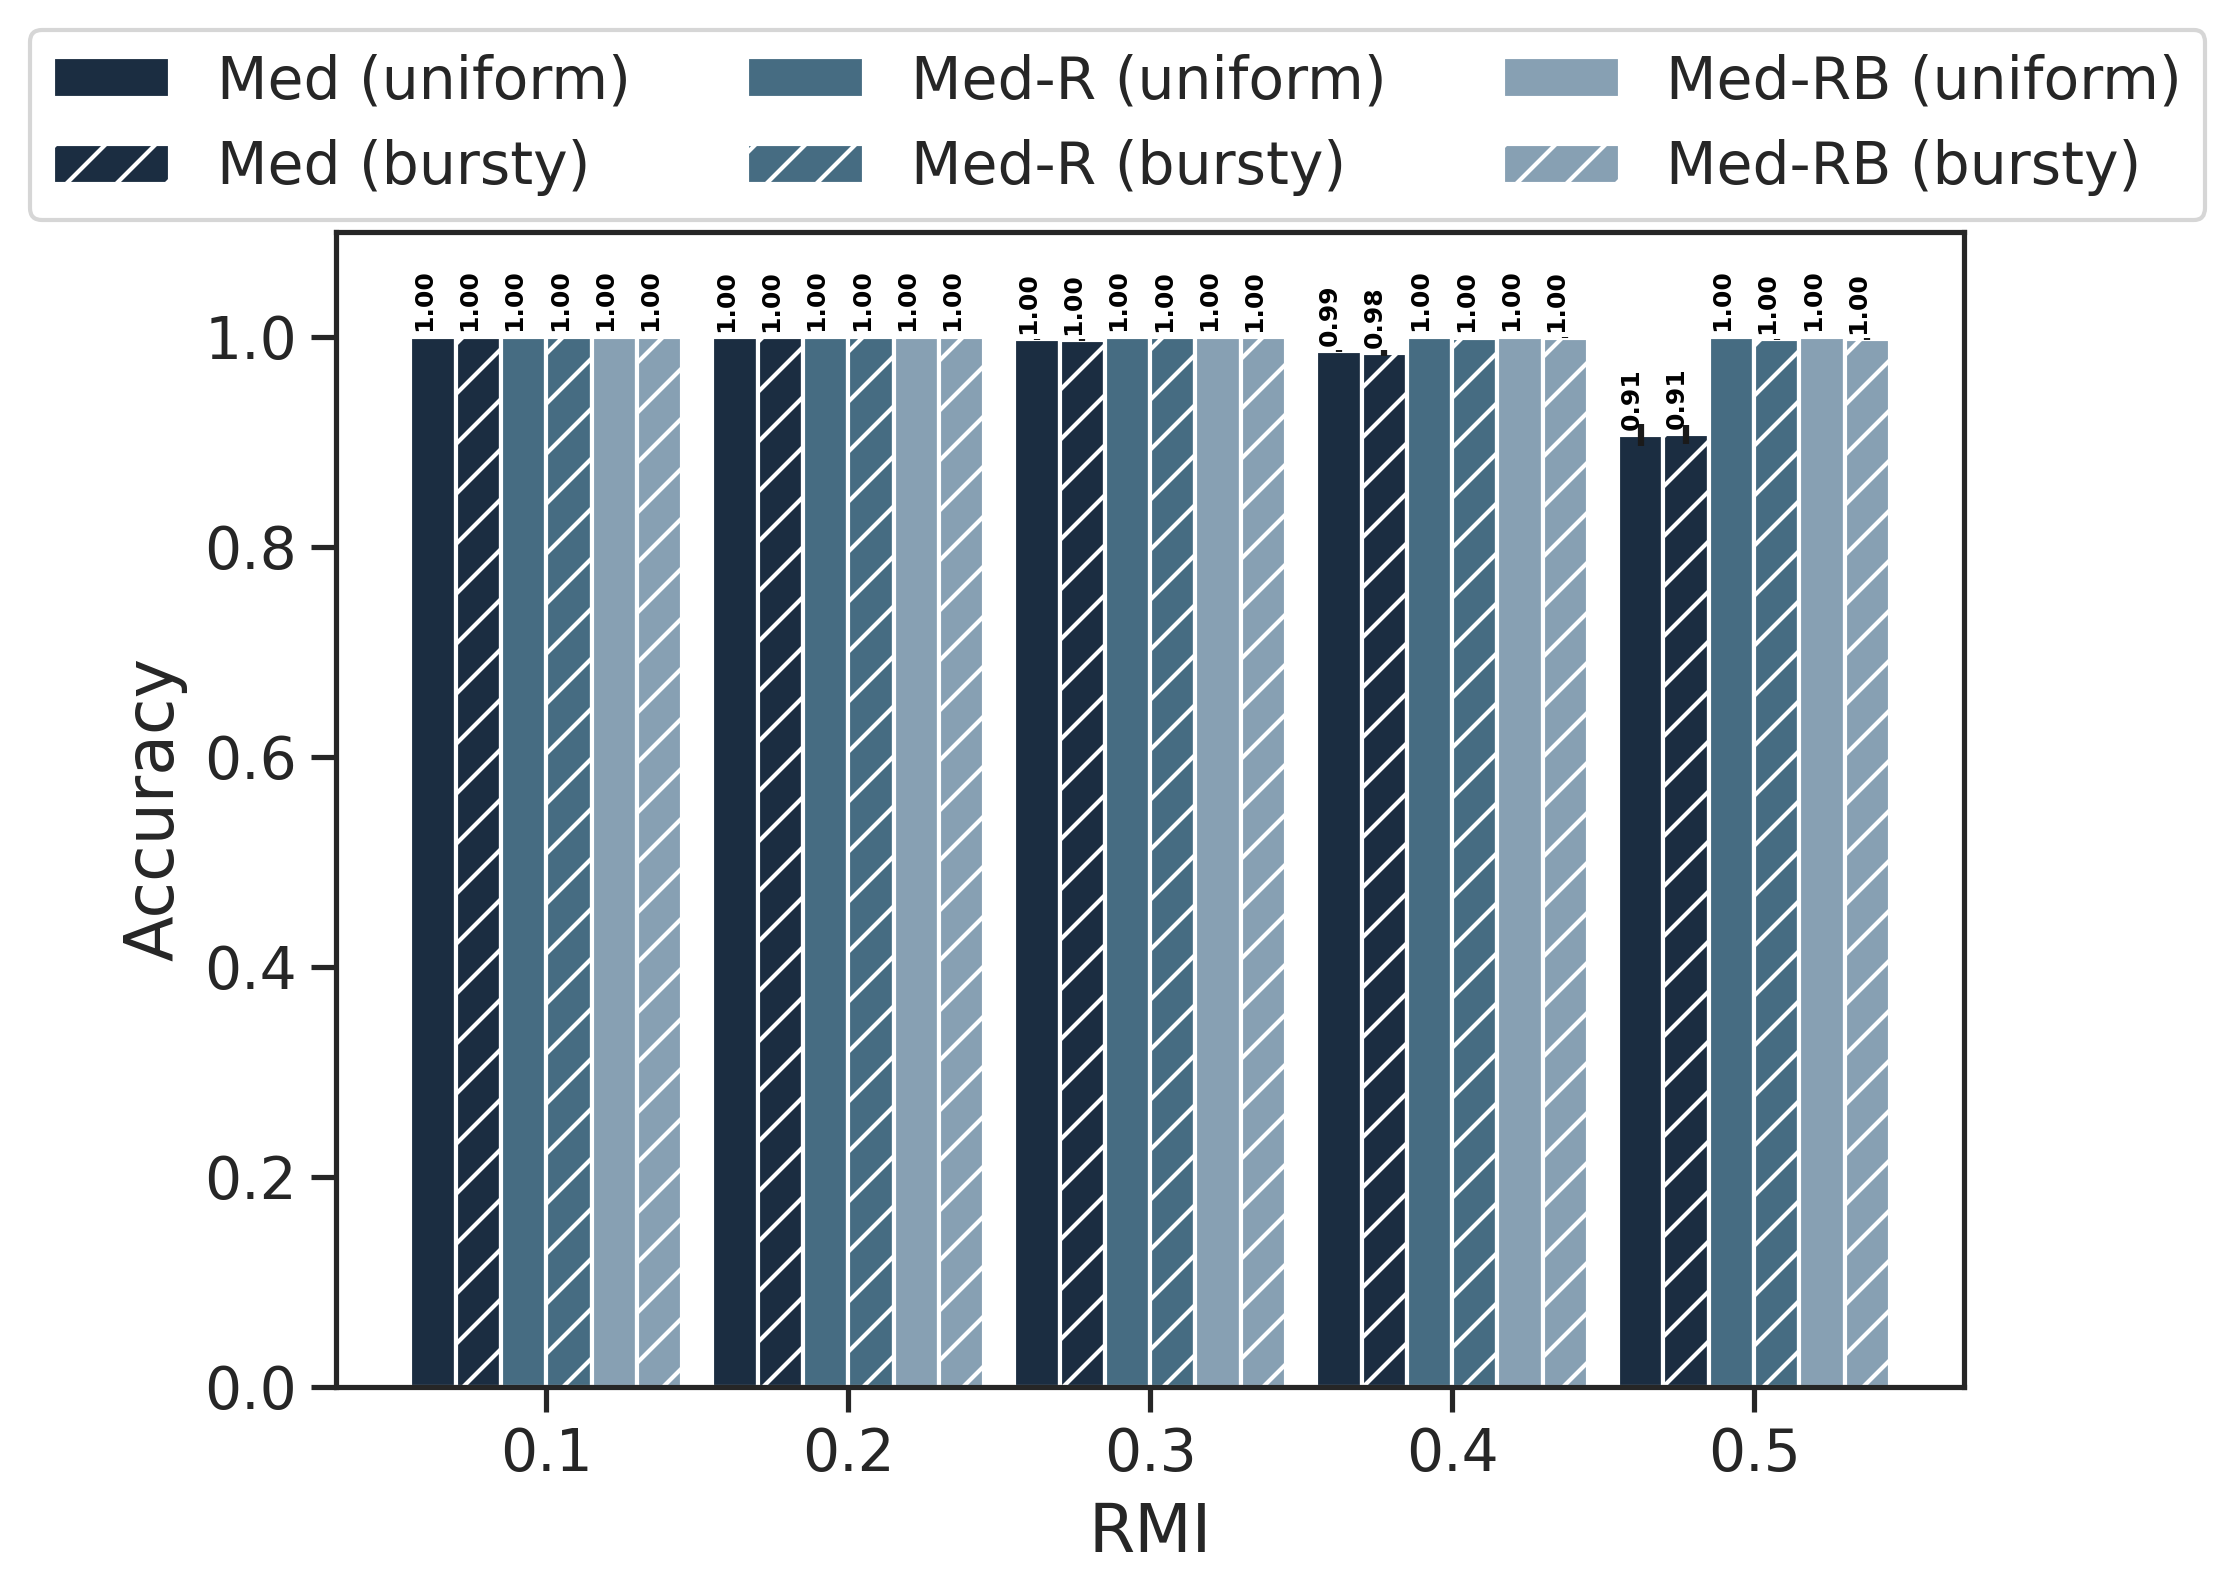

In [ ]:
img_name = "desmo_accuracy.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    # plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt)) 

    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

In [ ]:
print("Doing the bars...")
df_bar = df_goodo2.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

Doing the bars...


Doing desmo_accuracy_tail.png
desmo_accuracy_tail.png Done!


/tmp/ipykernel_2614/1234848352.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/1234848352.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/1234848352.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/1234848352.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/1234848352.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mea

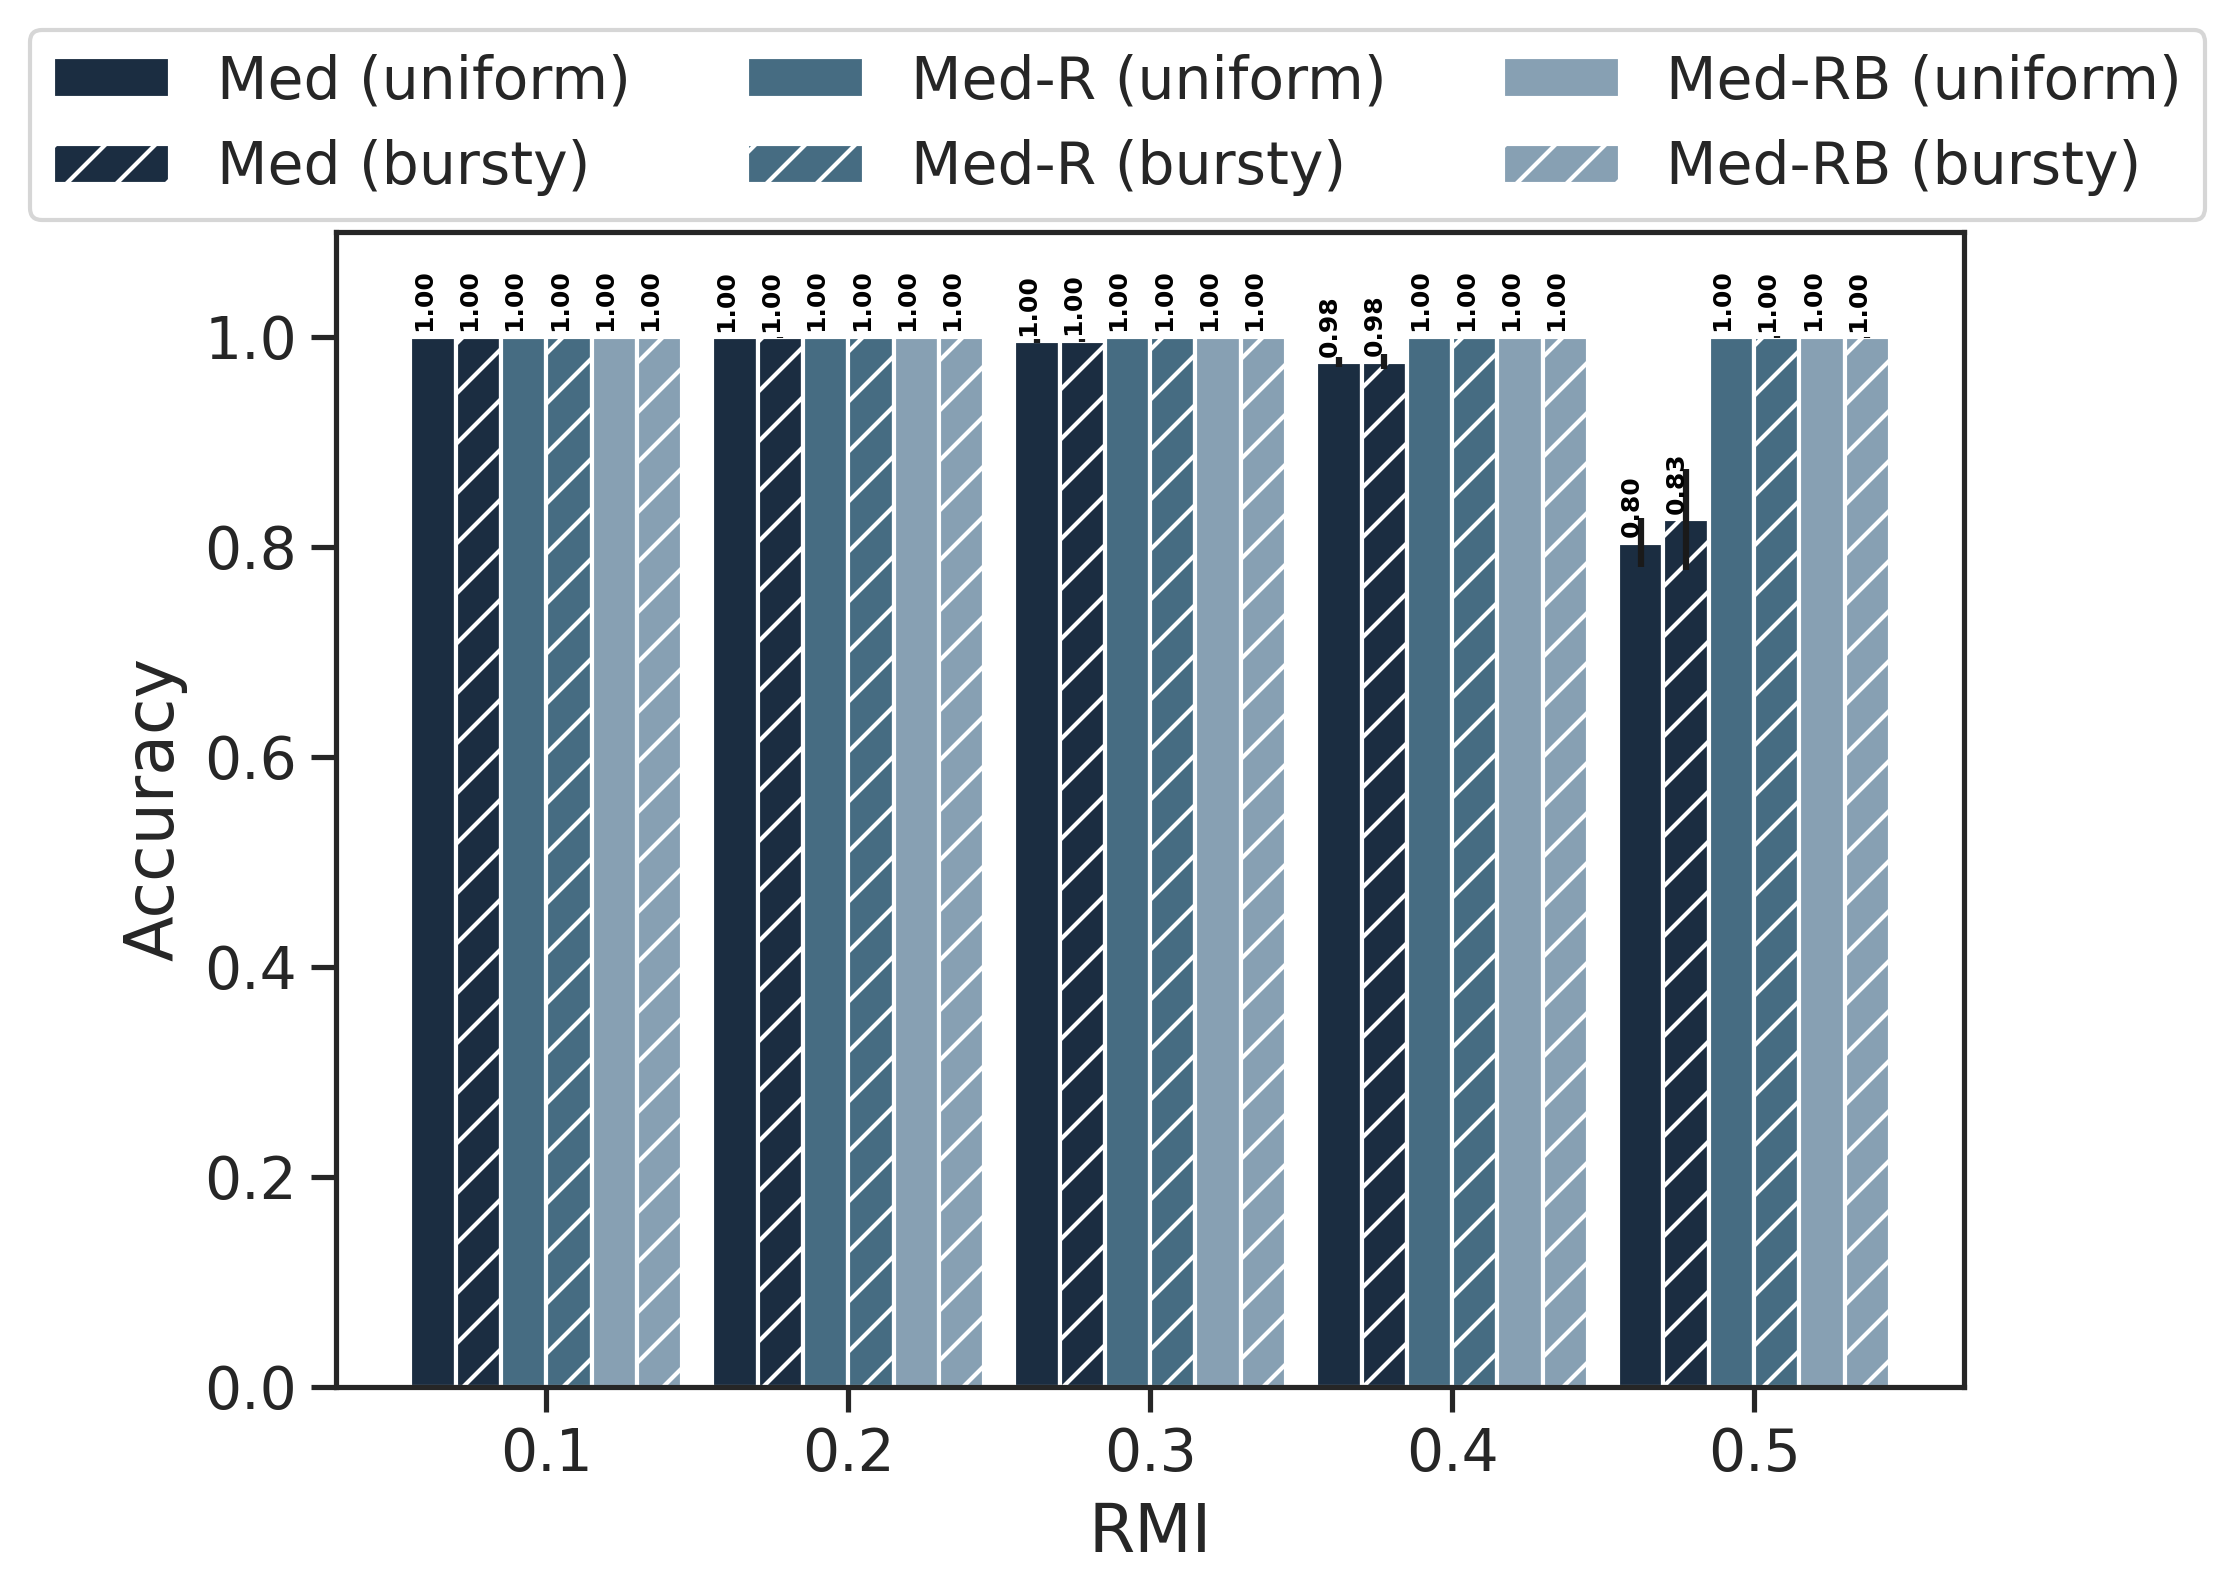

In [ ]:
img_name = "desmo_accuracy_tail.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

Doing the bars...
Doing desmo_accuracy_avg_tail.png


/tmp/ipykernel_2614/950773107.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/950773107.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/950773107.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/950773107.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/950773107.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].t

desmo_accuracy_avg_tail.png Done!


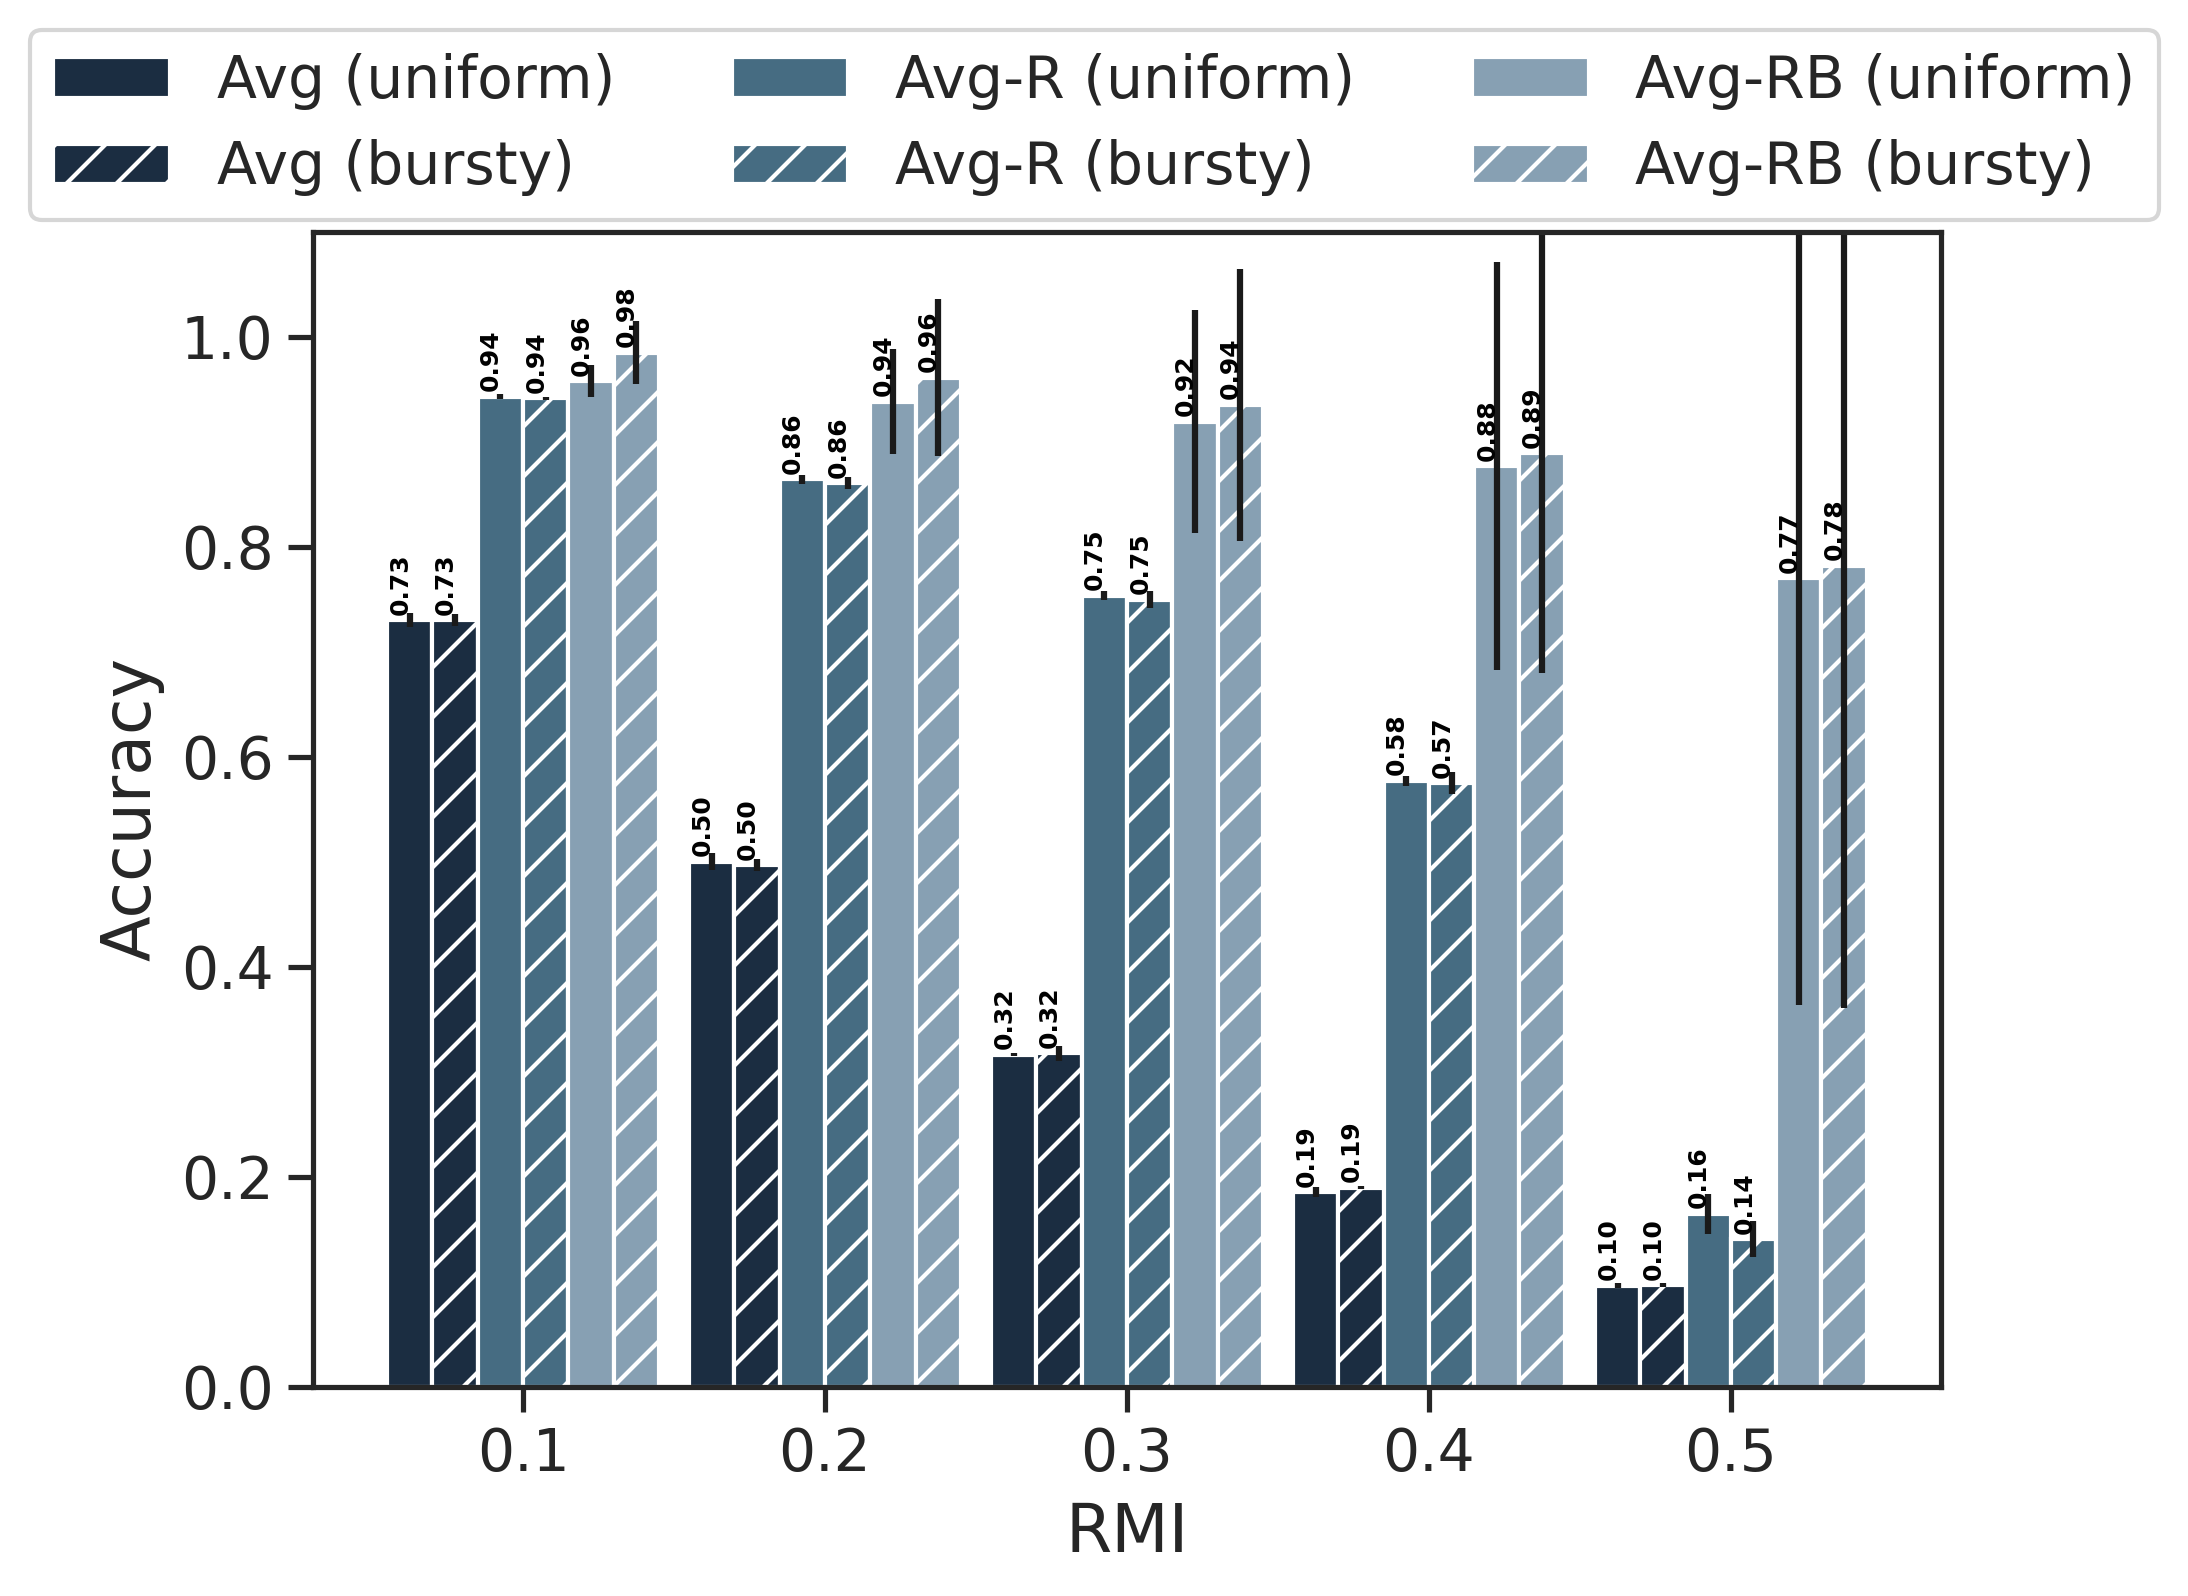

In [ ]:
# Accuracy full with avg

df_tail_2 = df_avg.drop(df_avg[(df_avg['Epoch'] < 2000)].index) # FIXME should be 2000
df_goodo2_avg = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)

print("Doing the bars...")
df_bar = df_goodo2_avg.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_avg_tail.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Avg (uniform)', 'Avg (bursty)', 'Avg-R (uniform)', 'Avg-R (bursty)', 'Avg-RB (uniform)', 'Avg-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


Doing the bars...
Doing desmo_accuracy_wavg_tail.png


/tmp/ipykernel_2614/4020575613.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/4020575613.py:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/4020575613.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/4020575613.py:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/4020575613.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mea

desmo_accuracy_wavg_tail.png Done!


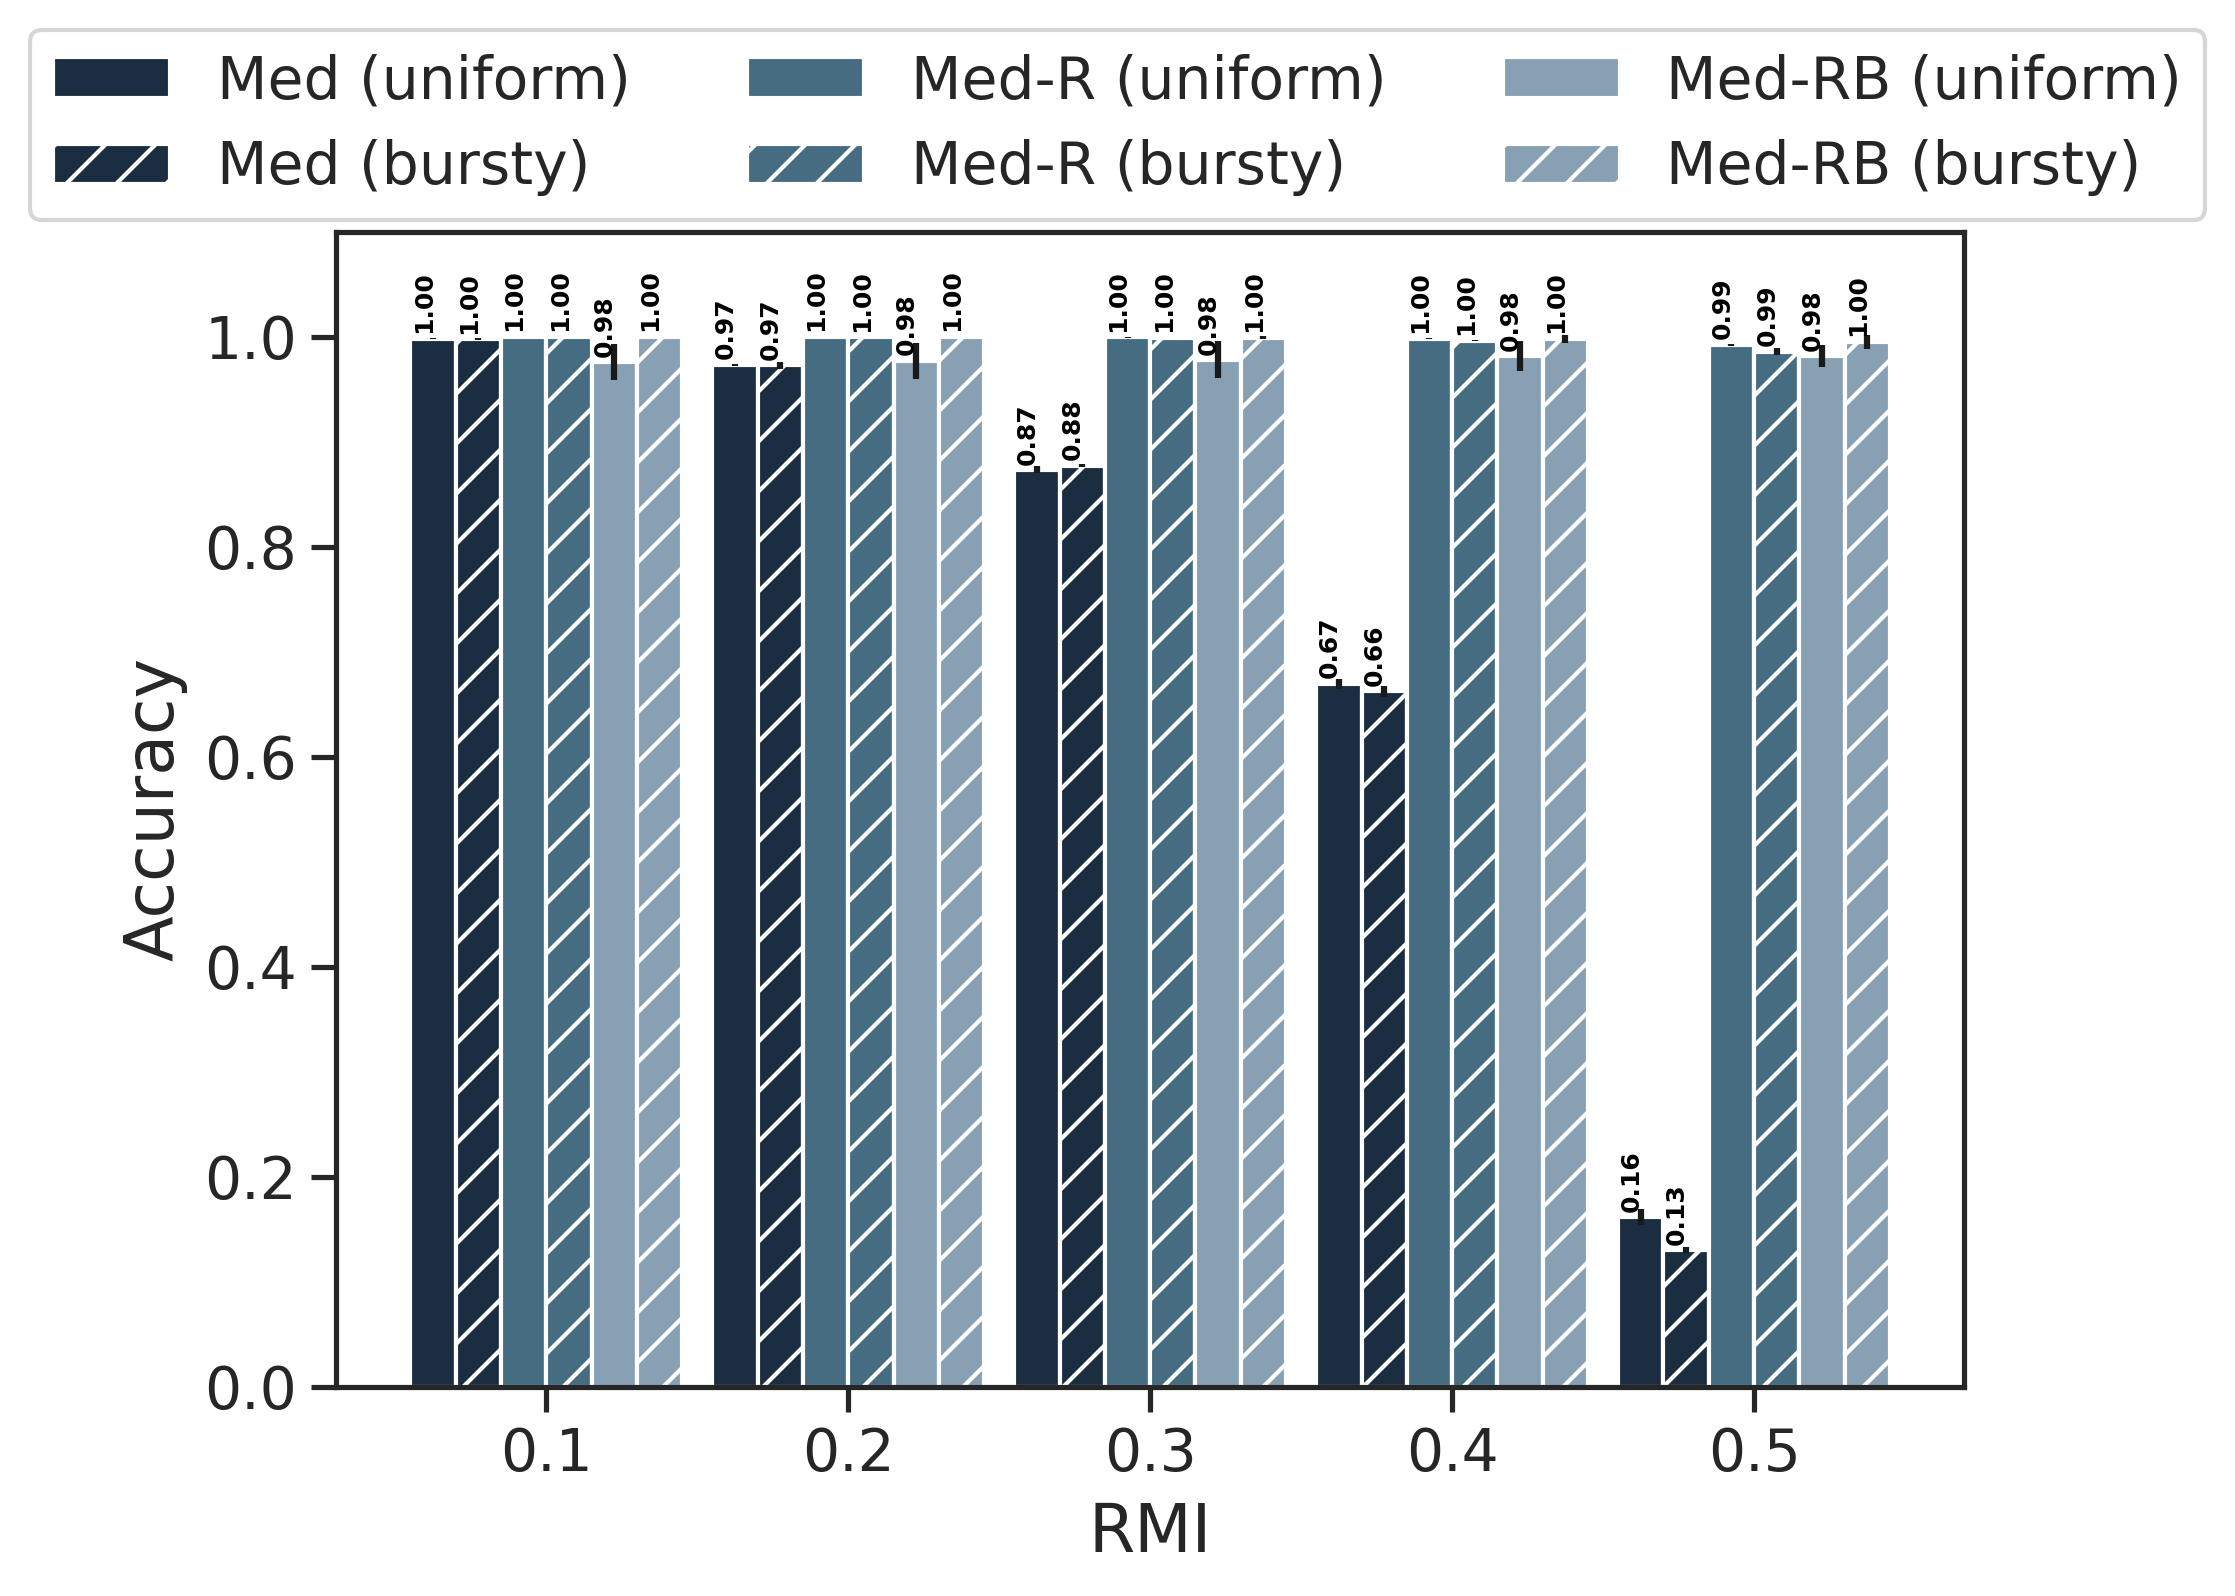

In [ ]:
# Accuracy full with wavg

# Take the tail and 
df_tail_2 = df_wavg.drop(df_wavg[(df_wavg['Epoch'] < 2000)].index) # FIXME should be 2000
df_goodo2_avg = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)

print("Doing the bars...")
df_bar = df_goodo2_avg.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_wavg_tail.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

Doing the bars...
Doing desmo_accuracy_wavg_tail.png


/tmp/ipykernel_2614/3138451923.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/3138451923.py:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/3138451923.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_2614/3138451923.py:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
/tmp/ipykernel_2614/3138451923.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mea

desmo_accuracy_wavg_tail.png Done!


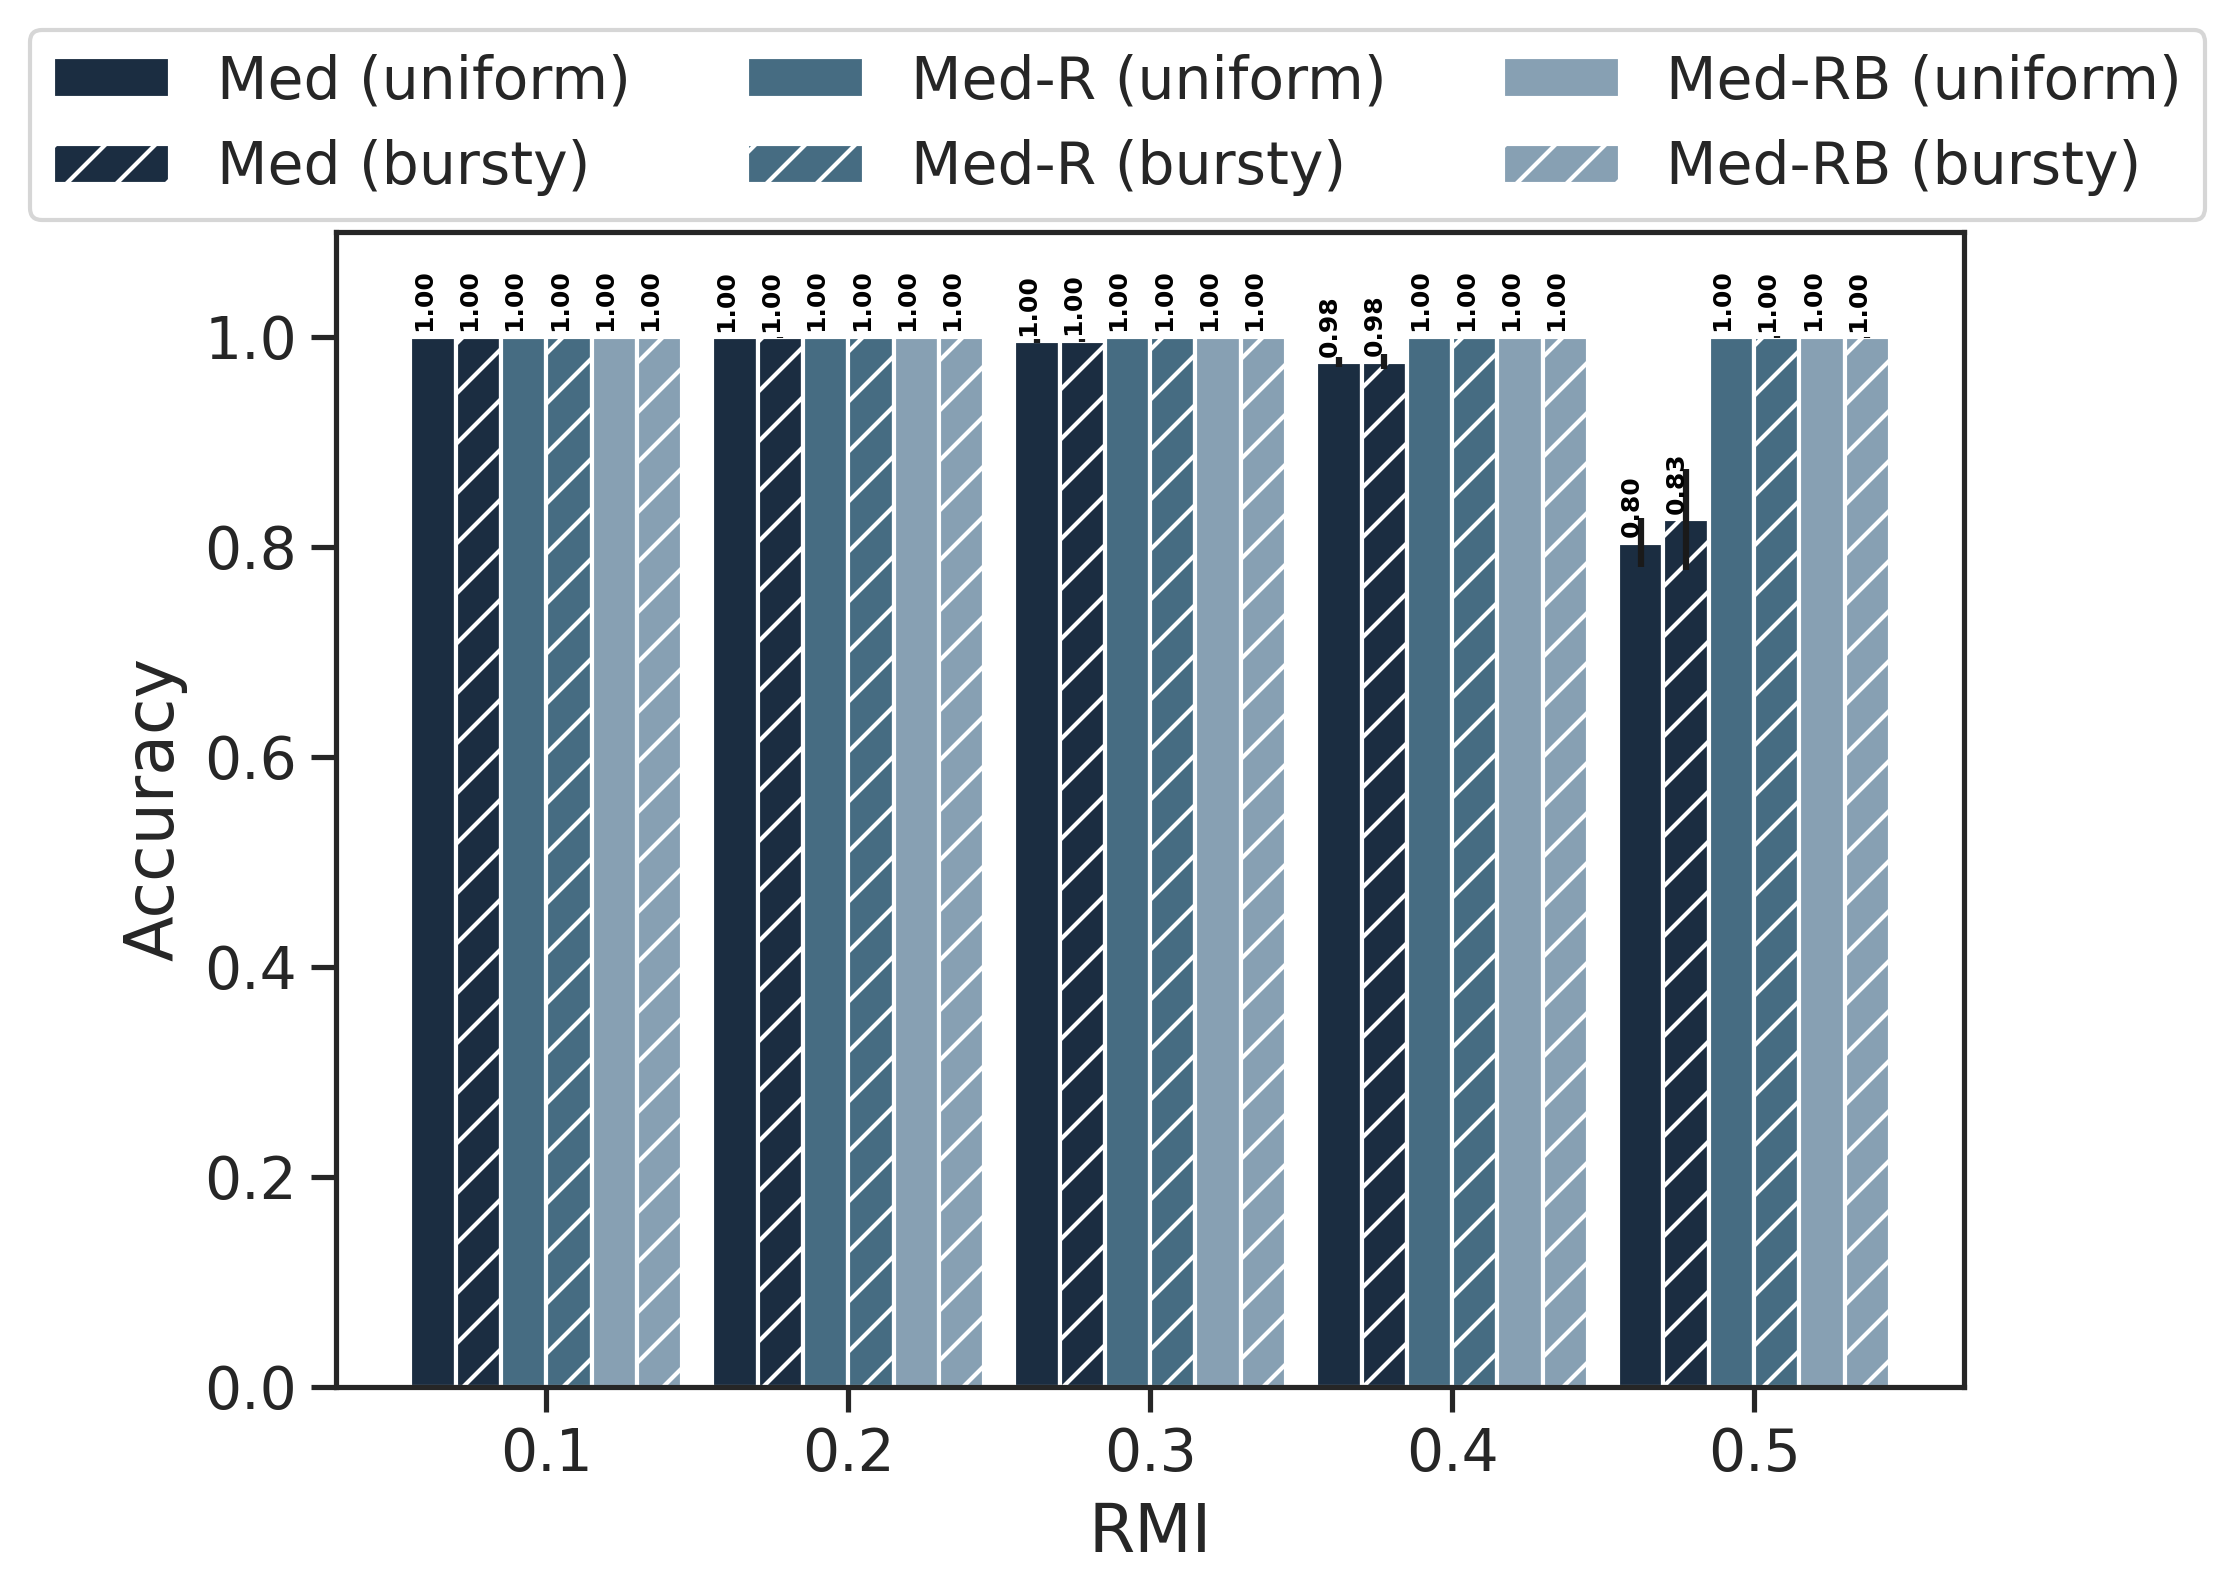

In [ ]:
# Accuracy full with wmed

# Take the tail and 
df_tail_2 = df_wmed.drop(df_wmed[(df_wmed['Epoch'] < 2000)].index) # FIXME should be 2000
df_goodo2_wmed = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)

print("Doing the bars...")
df_bar = df_goodo2_wmed.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_wavg_tail.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

/tmp/ipykernel_11189/3687404595.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_temp_avg = pd.concat([df_temp_avg, df_goodo2_avg], ignore_index=True)


Doing the bars...
Doing desmo_accuracy_tail_avg_all.png


/tmp/ipykernel_11189/3687404595.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
/tmp/ipykernel_11189/3687404595.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
/tmp/ipykernel_11189/3687404595.py:52: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
/tmp/ipykernel_11189/3687404595.py:52: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
/tmp/ipykernel_11189/3687404595.py:51: UserWarning: Boolean Series key will be rei

desmo_accuracy_tail_avg_all.png Done!


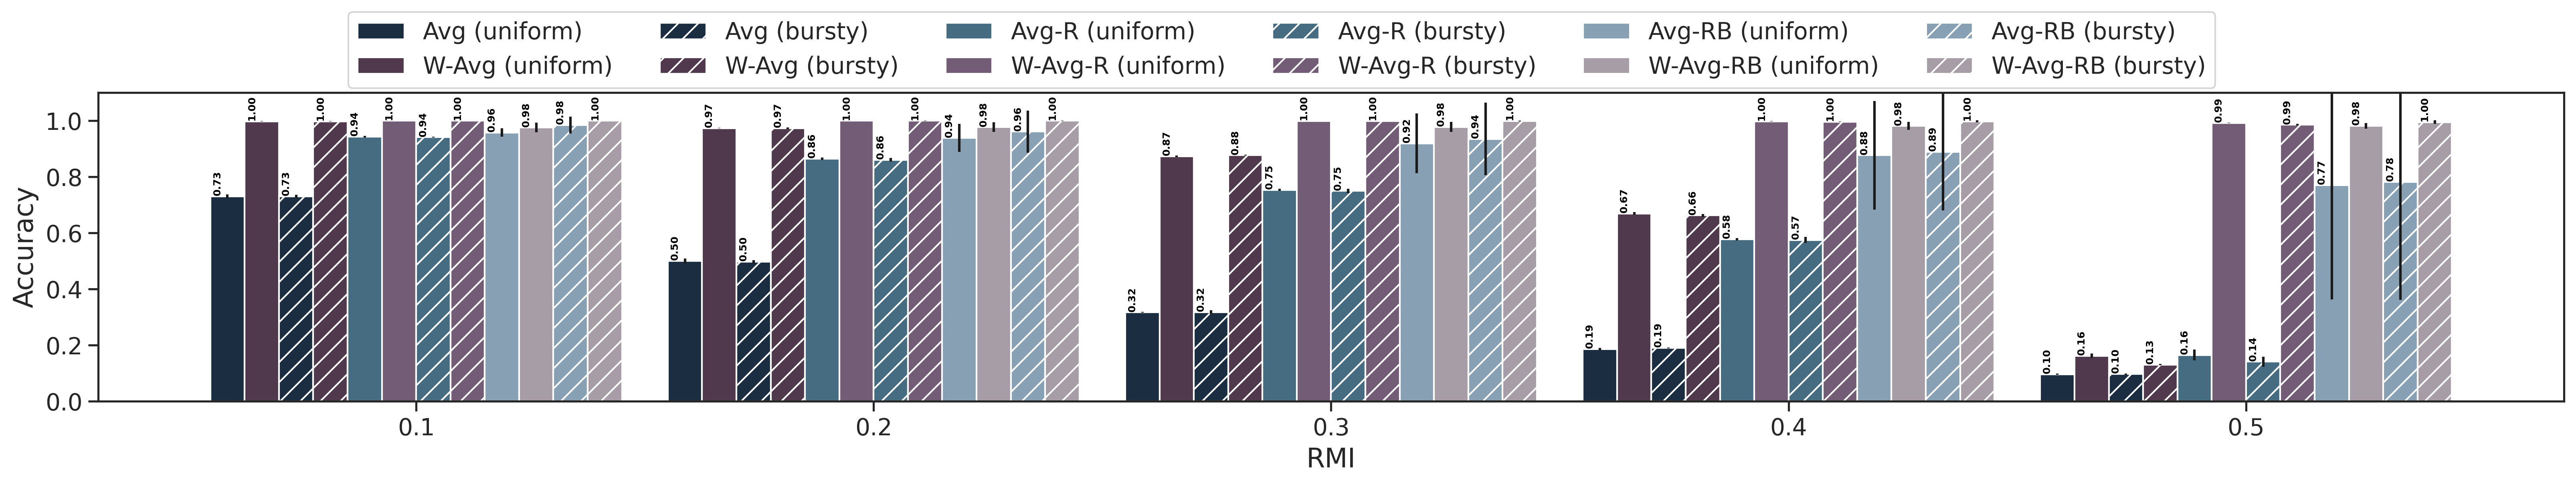

In [40]:
# Accuracy full-tail

df_tail_2 = df_avg.drop(df_avg[(df_avg['Epoch'] < 2000)].index)
df_goodo2_avg = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)

# create an empty dataset df_temp
df_temp_avg = pd.DataFrame(columns=df_goodo2_avg.columns)

# join df_temp with df_goodo2_avg
df_temp_avg = pd.concat([df_temp_avg, df_goodo2_avg], ignore_index=True)

df_tail_2 = df_wavg.drop(df_wavg[(df_wavg['Epoch'] < 2000)].index)
df_goodo2_wavg = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)
df_temp_avg = pd.concat([df_temp_avg, df_goodo2_wavg], ignore_index=True)


print("Doing the bars...")
df_bar = df_temp_avg.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival', 'truth'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival', 'truth'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_tail_avg_all.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())
    truths = df_bar['truth'].unique()

    width = 0.75

    colors_w = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors_w = ["#50394C" , "#735D76" , "#A69DA6"]
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots(figsize=(22, 5))

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * len(truths) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            for z, truth in enumerate(truths):
                xvals = xvals + width
                xlist = xvals.tolist()
                yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
                yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
                plt.bar(xvals, yvals, color = colors[i] if z == 0 else colors_w[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
                for h in range(len((yvals))):
                    ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
                # for pos, y, err in zip(xvals, yvals, yerrs):
                #     ax.errorbar(pos, y, err, lw = 2,
                #                 capsize = 4, capthick = 2,
                #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.30), ncol=6, labels=['Avg (uniform)', 'W-Avg (uniform)', 'Avg (bursty)', 'W-Avg (bursty)', 'Avg-R (uniform)', 'W-Avg-R (uniform)', 'Avg-R (bursty)', 'W-Avg-R (bursty)', 'Avg-RB (uniform)', 'W-Avg-RB (uniform)', 'Avg-RB (bursty)', 'W-Avg-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.tight_layout()
    plt.savefig(img_name, dpi=200, bbox_inches='tight')
    print(img_name + " Done!")

/tmp/ipykernel_11189/2264548235.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_temp_med = pd.concat([df_temp_med, df_goodo2_med], ignore_index=True)


Doing the bars...
Doing desmo_accuracy_tail_med_all.png


/tmp/ipykernel_11189/2264548235.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
/tmp/ipykernel_11189/2264548235.py:51: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
/tmp/ipykernel_11189/2264548235.py:52: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
/tmp/ipykernel_11189/2264548235.py:52: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
/tmp/ipykernel_11189/2264548235.py:51: UserWarning: Boolean Series key will be rei

desmo_accuracy_tail_med_all.png Done!


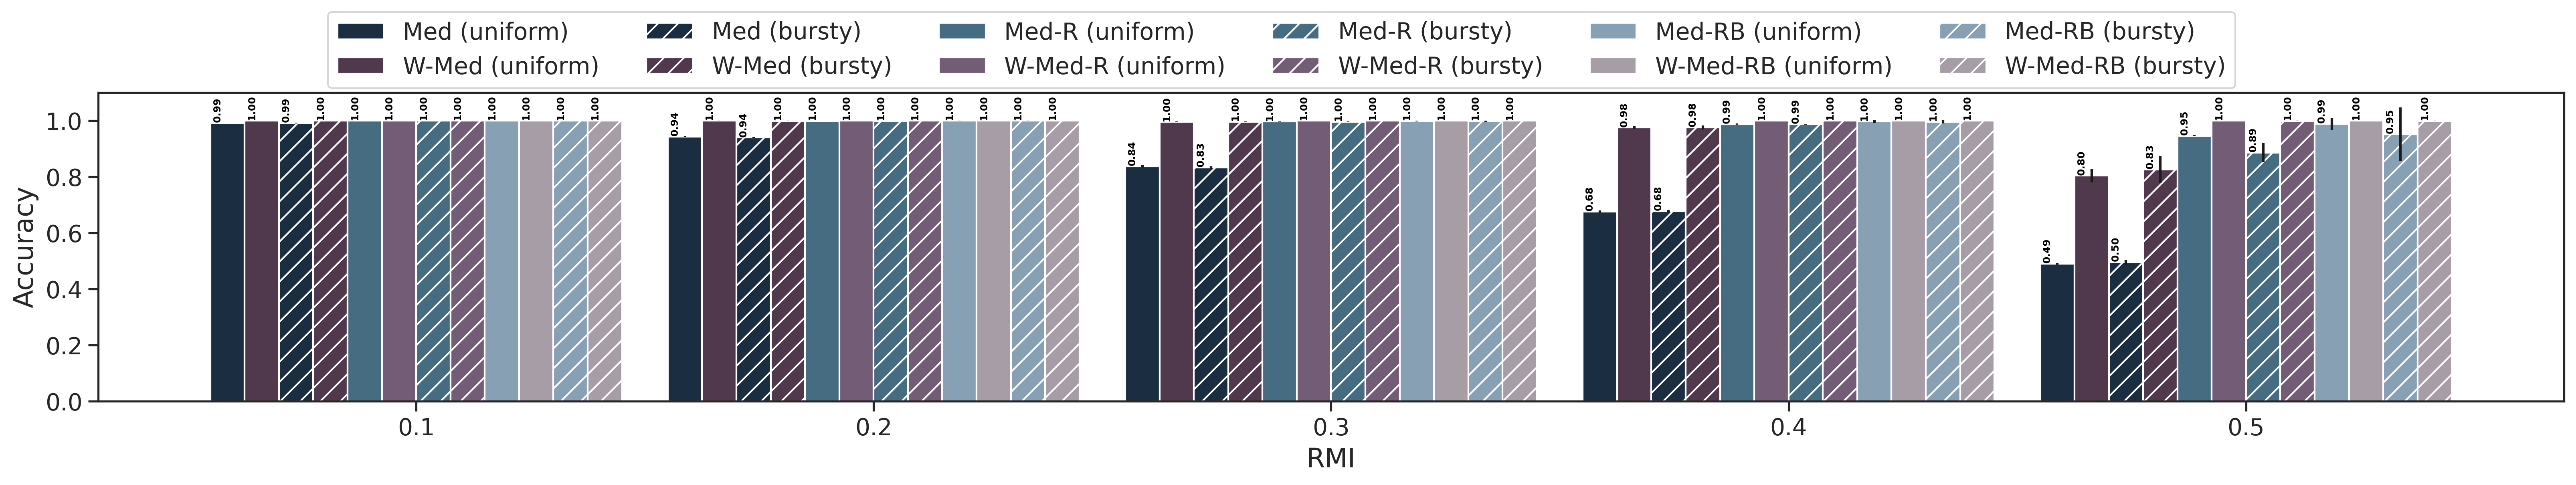

In [39]:
# Accuracy full-tail

df_tail_2 = df_med.drop(df_med[(df_med['Epoch'] < 2000)].index)
df_goodo2_med = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)

# create an empty dataset df_temp
df_temp_med = pd.DataFrame(columns=df_goodo2_med.columns)

# join df_temp with df_goodo2_avg
df_temp_med = pd.concat([df_temp_med, df_goodo2_med], ignore_index=True)

df_tail_2 = df_wmed.drop(df_wmed[(df_wmed['Epoch'] < 2000)].index)
df_goodo2_wmed = df_tail_2.drop(df_tail_2[(df_tail_2['Ratio Malicious Oracles'] != 0.0)].index)
df_temp_med = pd.concat([df_temp_med, df_goodo2_wmed], ignore_index=True)


print("Doing the bars...")
df_bar = df_temp_med.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival', 'truth'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)

df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival', 'truth'])['Accuracy'].agg(['mean','std']).reset_index()

img_name = "desmo_accuracy_tail_med_all.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())
    truths = df_bar['truth'].unique()

    width = 0.75

    colors_w = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    colors_w = ["#50394C" , "#735D76" , "#A69DA6"]
    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots(figsize=(22, 5))

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * len(truths) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            for z, truth in enumerate(truths):
                xvals = xvals + width
                xlist = xvals.tolist()
                yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['mean'].tolist()
                yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo][df_bar['truth'] == truth]['std'].tolist()
                plt.bar(xvals, yvals, color = colors[i] if z == 0 else colors_w[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
                for h in range(len((yvals))):
                    ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
                # for pos, y, err in zip(xvals, yvals, yerrs):
                #     ax.errorbar(pos, y, err, lw = 2,
                #                 capsize = 4, capthick = 2,
                #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.30), ncol=6, labels=['Med (uniform)', 'W-Med (uniform)', 'Med (bursty)', 'W-Med (bursty)', 'Med-R (uniform)', 'W-Med-R (uniform)', 'Med-R (bursty)', 'W-Med-R (bursty)', 'Med-RB (uniform)', 'W-Med-RB (uniform)', 'Med-RB (bursty)', 'W-Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.tight_layout()
    plt.savefig(img_name, dpi=200, bbox_inches='tight')
    print(img_name + " Done!")

/tmp/ipykernel_11189/1475524522.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


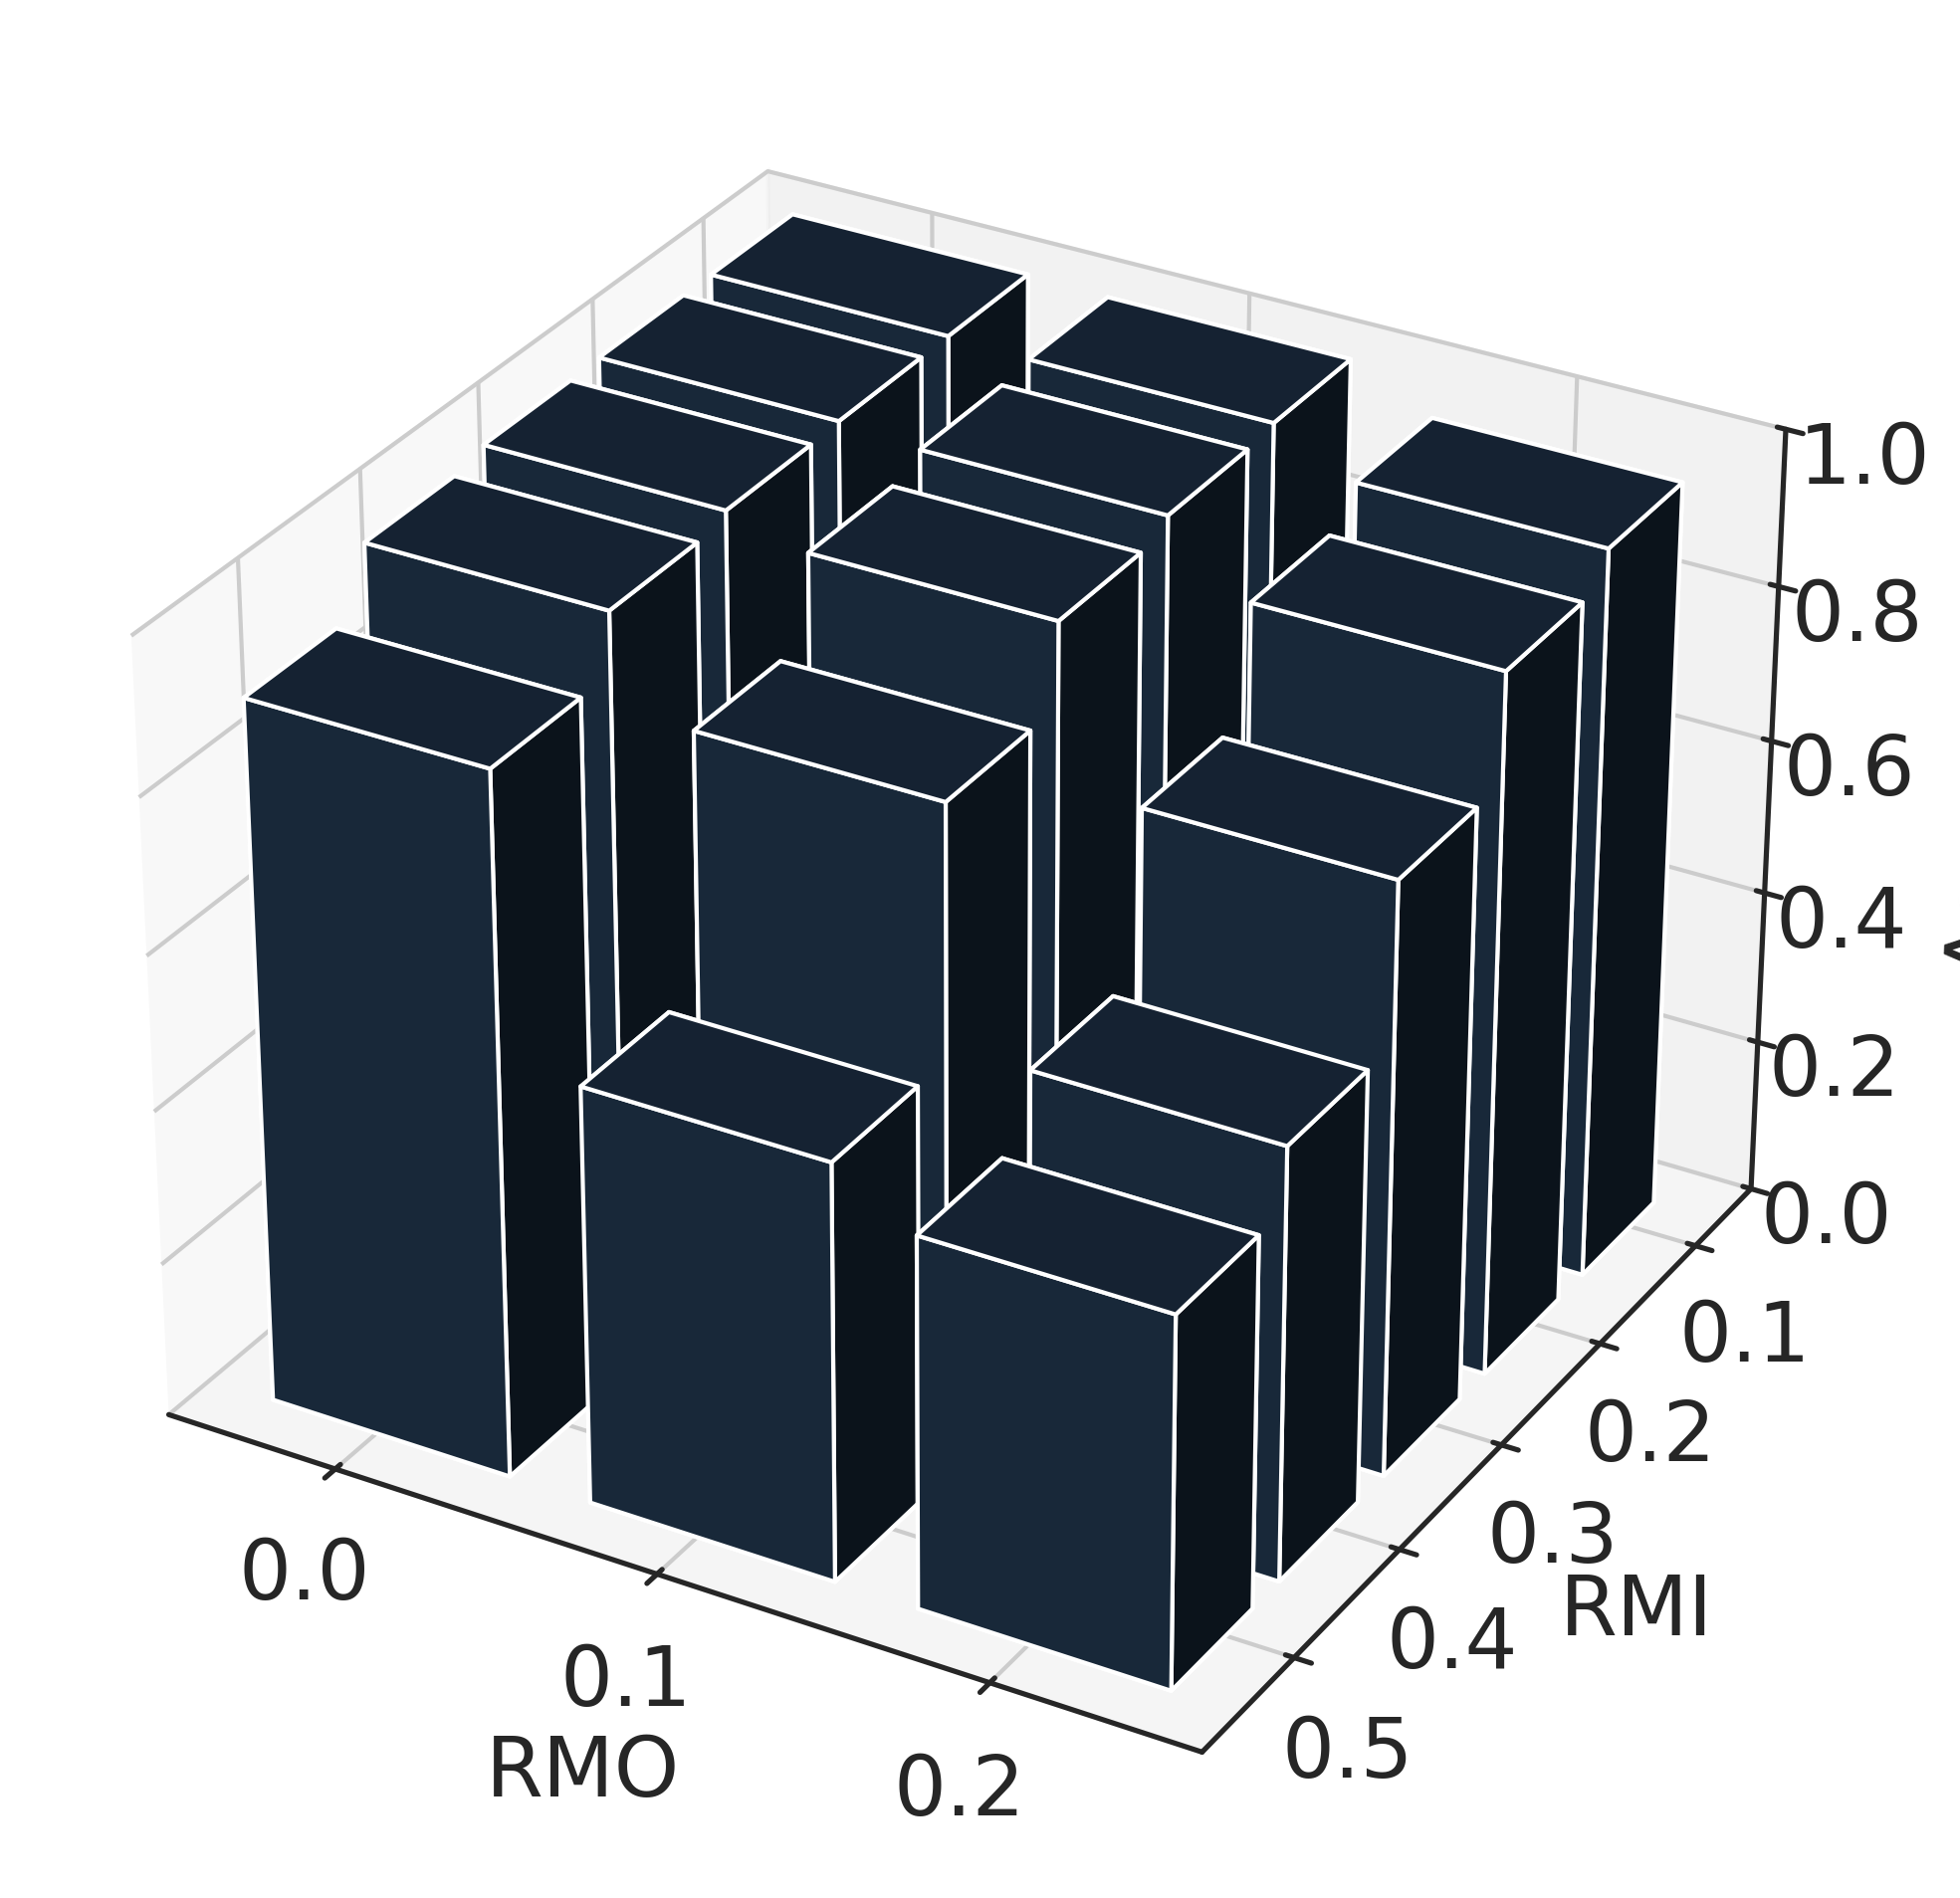

In [ ]:
img_name = "3d_accuracy_1.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 0)].index)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color="#1B2D41")
    ax.set_zlim(0, 1)

    xticks = np.arange(len(xvals))
    plt.xticks(xticks + 0.33, xticks)
    yticks = np.arange(len(yvals))
    plt.yticks(yticks + 0.5, yticks)
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)

    ax.set_xlabel('RMO', labelpad=10)
    ax.set_ylabel('RMI', labelpad=10)
    ax.set_zlabel('Accuracy')
    #plt.title('Algorithm = Med')
    plt.savefig(img_name, dpi=200)

          Epoch  sources  malign  ban_sources  ban_malign  consensus  \
141000        0      100      20            0           0  25.045268   
141001        1      100      20            0           0  25.036577   
141002        2      100      20            0           0  25.107664   
141003        3      100      20            0           0  24.950961   
141004        4      100      20            0           0  23.434011   
...         ...      ...     ...          ...         ...        ...   
37106987   2995      100      20            0           0  24.908330   
37106988   2996      100      20            0           0  25.006595   
37106989   2997      100      20            0           0  25.192277   
37106990   2998      100      20            0           0  24.475040   
37106991   2999      100      20            0           0  24.814924   

          rep_benign  rep_malign  rep_min  ratio_malign  ...  tolerance  \
141000      0.017803    0.000000     -0.6           0.2  ...

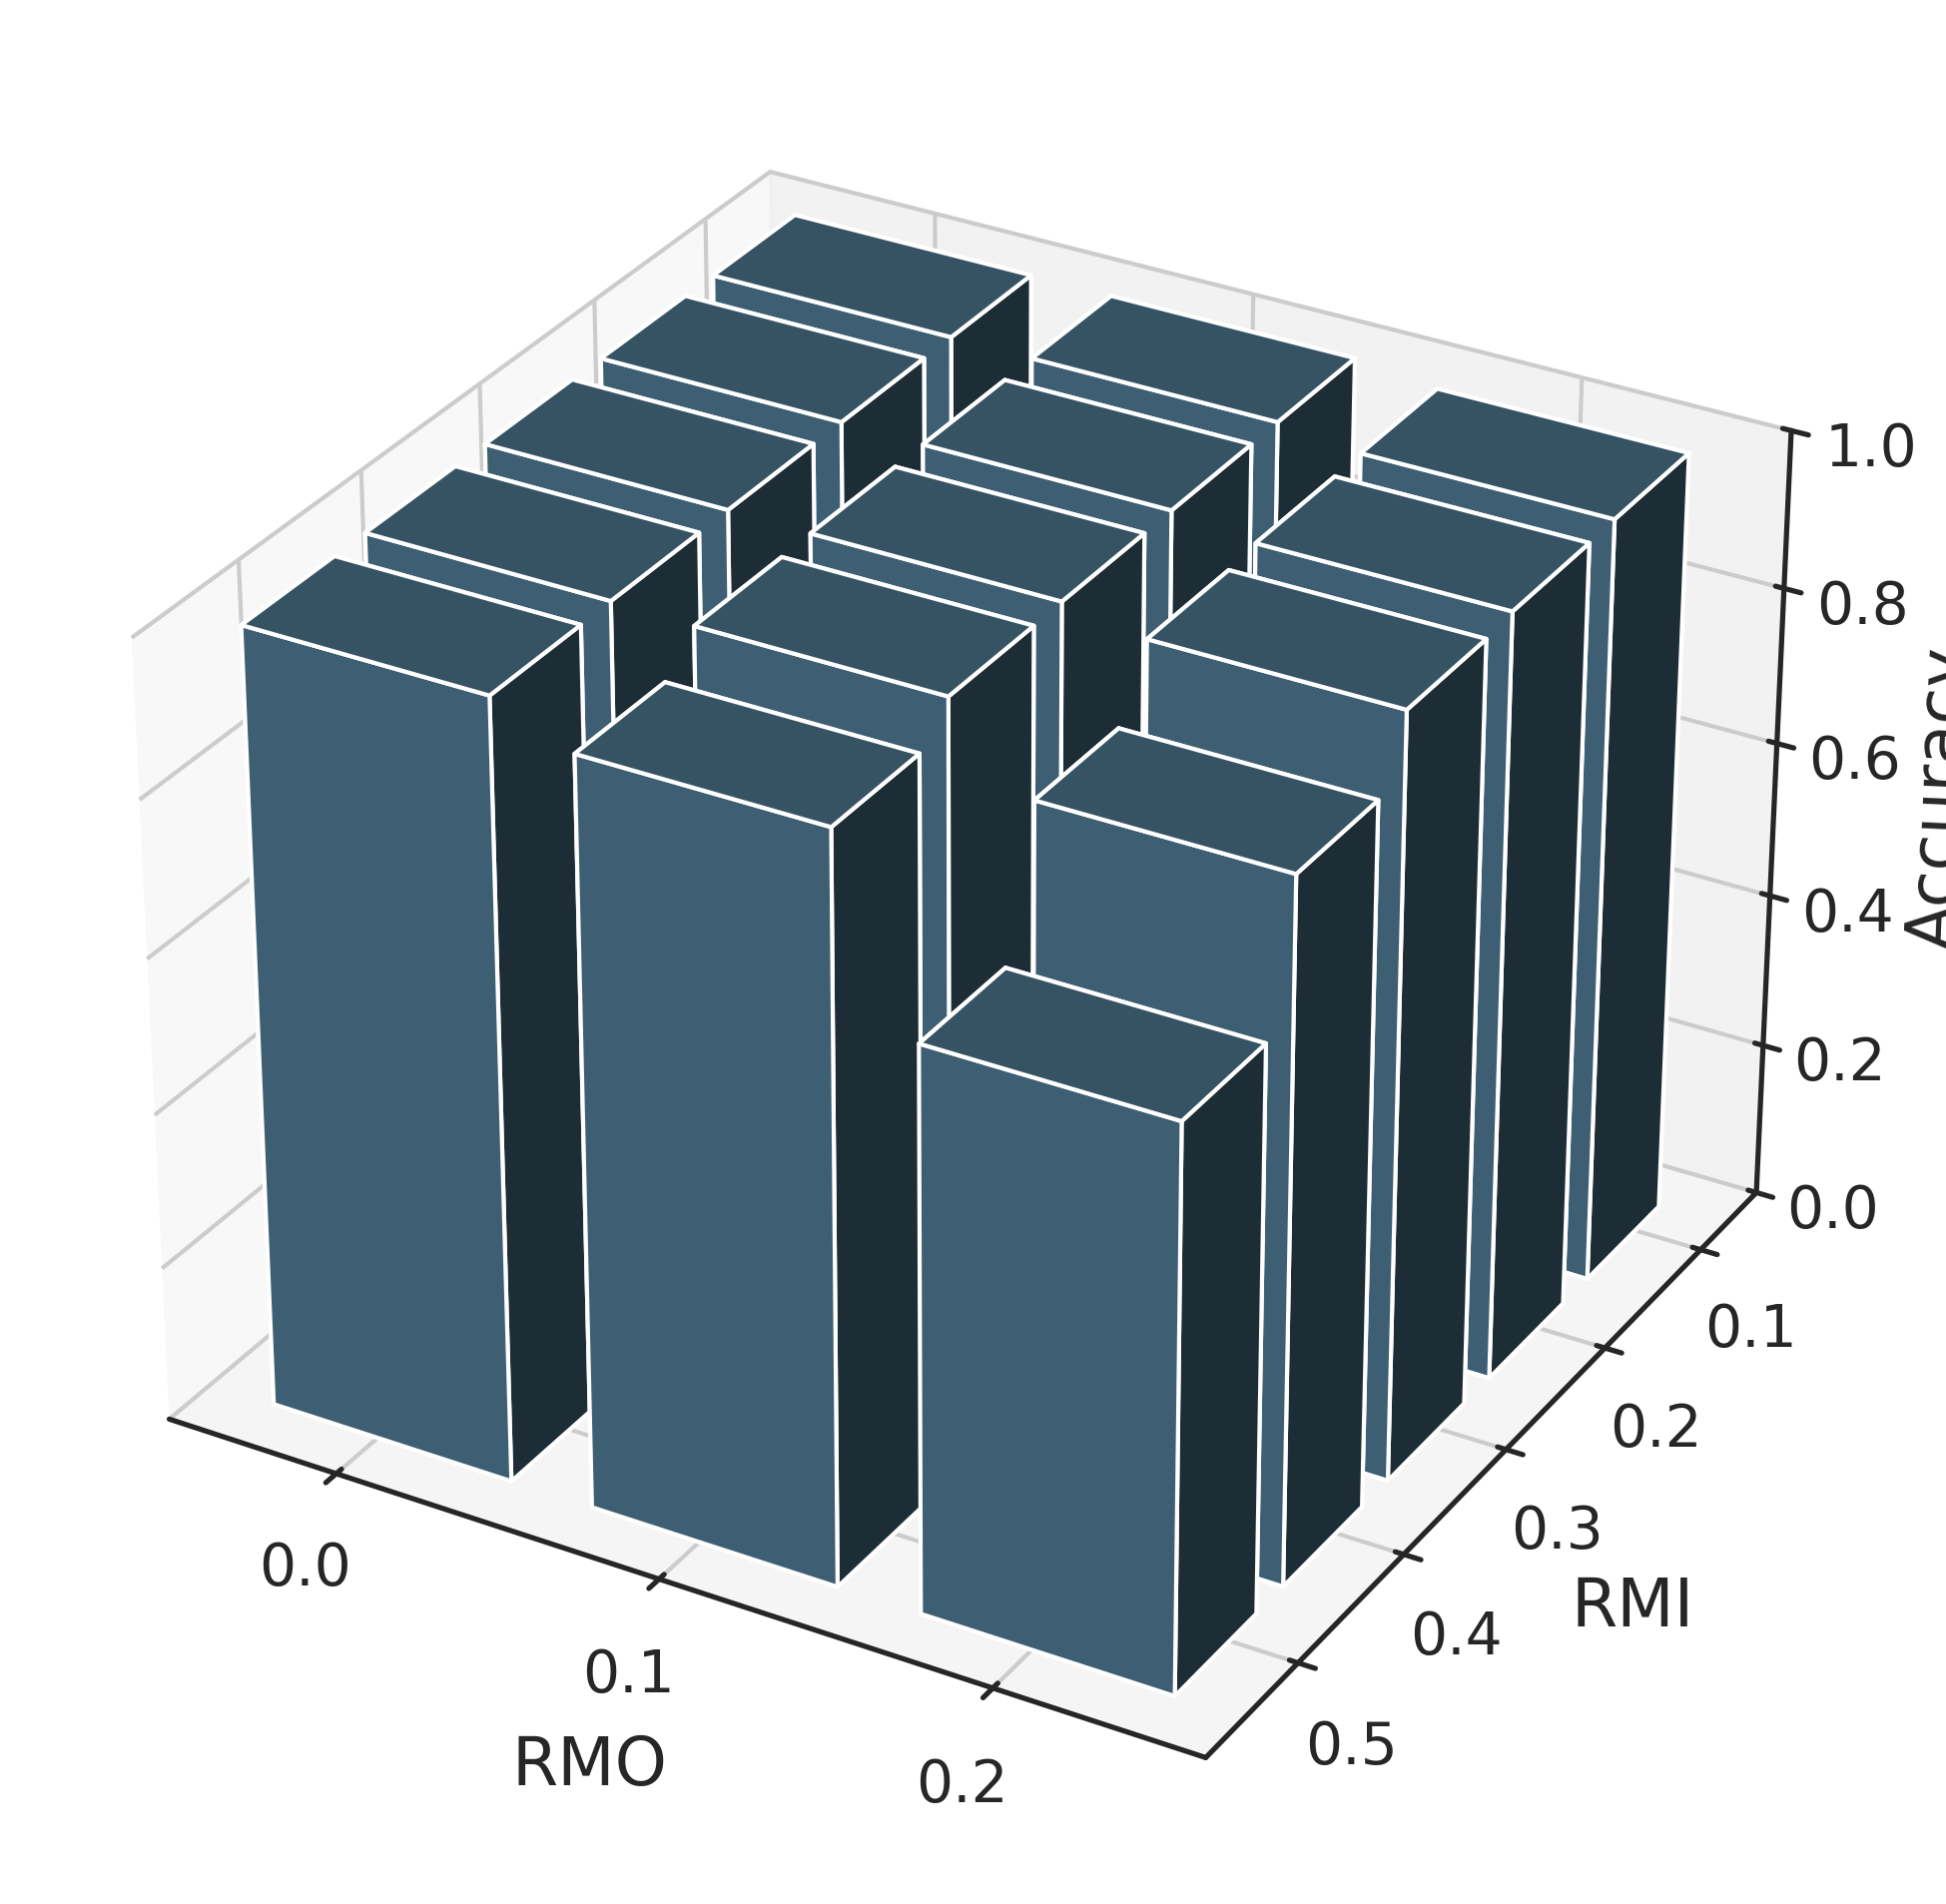

In [ ]:
img_name = "3d_accuracy_2.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 1)].index)

    print(this_df)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
            print(xvals[_x], yvals[_y], values[_x][_y])
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color='#466C82')

    #ax.set_xticks(np.arange(len(xvals)))
    xticks = np.arange(len(xvals))
    plt.xticks(xticks + 0.33, xticks)
    yticks = np.arange(len(yvals))
    plt.yticks(yticks + 0.5, yticks)
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)
    ax.set_zlim(0, 1)
    ax.set_xlabel('RMO', labelpad=10)
    ax.set_ylabel('RMI', labelpad=10)
    ax.set_zlabel('Accuracy')
    #plt.title('Algorithm = Med-R')
    plt.savefig(img_name, dpi=200)

          Epoch  sources  malign  ban_sources  ban_malign  consensus  \
12000         0      100      30            0           0  24.858763   
12001         1      100      30            0           0  24.817801   
12002         2      100      30            0           0  25.134832   
12003         3      100      30            0           0  24.929612   
12004         4      100      30            0           0  25.107659   
...         ...      ...     ...          ...         ...        ...   
37100987   2995      100      20           20          20  24.188477   
37100988   2996      100      20           20          20  24.394805   
37100989   2997      100      20           20          20  24.849134   
37100990   2998      100      20           20          20  24.644650   
37100991   2999      100      20           20          20  24.818137   

          rep_benign  rep_malign  rep_min  ratio_malign  ...  tolerance  \
12000       0.009574    0.000000     -0.6           0.3  ...

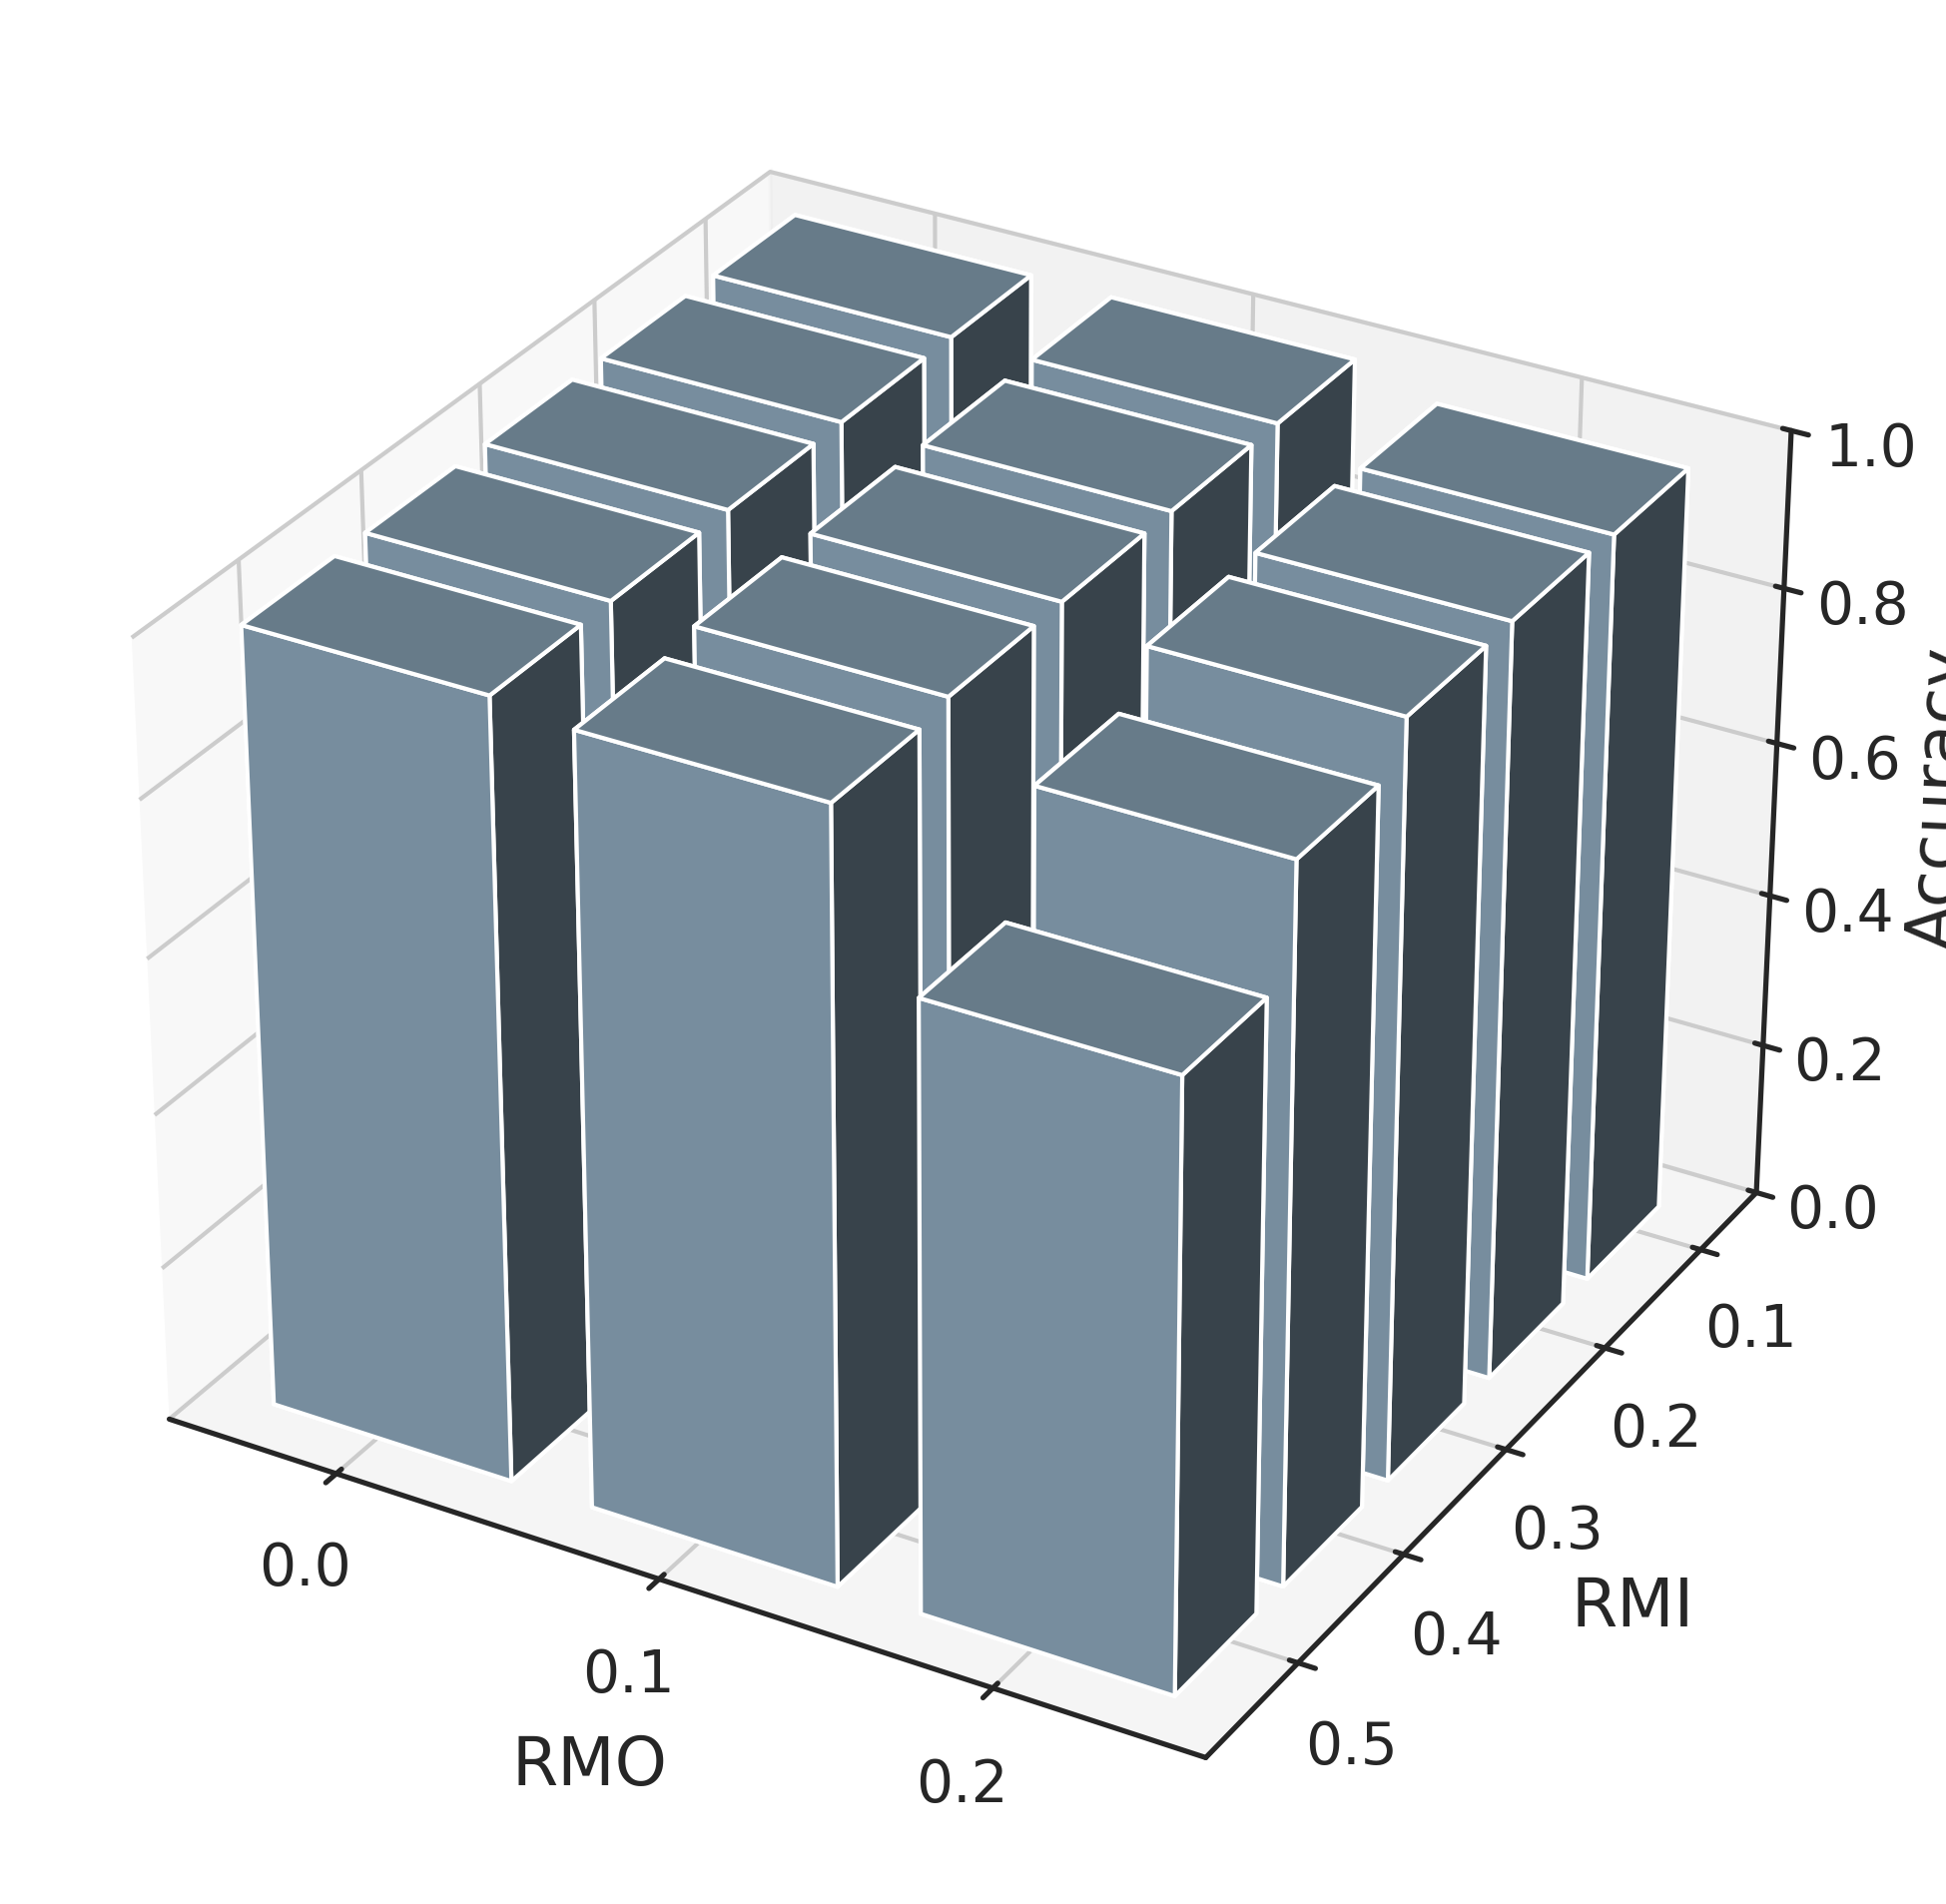

In [ ]:
img_name = "3d_accuracy_3.png"
if _REPLACE_ or not os.path.exists(img_name):
    this_df = df.drop(df[(df.Algorithm != 2)].index)

    print(this_df)

    xvals = sorted(this_df['Ratio Malicious Oracles'].unique())
    yvals = sorted(this_df['ratio_malign'].unique(), reverse=True)
    values = np.zeros(shape=(len(xvals), len(yvals)))
    for _x, _ in enumerate(values):
        for _y, __ in enumerate(_):
            values[_x][_y] = this_df.loc[(this_df['Ratio Malicious Oracles'] == xvals[_x]) & (this_df['ratio_malign'] == yvals[_y]), 'Consensus Accuracy'].mean()
            print(xvals[_x], yvals[_y], values[_x][_y])
    values = np.transpose(values)

    # Create a 3D bar plot with Seaborn
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xpos, ypos = np.meshgrid(np.arange(len(xvals)), np.arange(len(yvals)))
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)

    dx = dy = 0.75
    dz = values.flatten()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color="#87A0B3")
    ax.set_zlim(0, 1)

    xticks = np.arange(len(xvals))
    plt.xticks(xticks + 0.33, xticks)
    yticks = np.arange(len(yvals))
    plt.yticks(yticks + 0.5, yticks)
    ax.set_xticklabels(xvals)
    ax.set_yticklabels(yvals)

    ax.set_xlabel('RMO', labelpad=10)
    ax.set_ylabel('RMI', labelpad=10)
    ax.set_zlabel('Accuracy')
    plt.savefig(img_name, dpi=200)